# Agentic Finance Distributional Shield — Giant Notebook

This notebook builds a complete finance-grade version of the four-stage architecture:

\[
\text{Unstructured instruction}
\rightarrow
\text{typed Pydantic proposal}
\rightarrow
\text{deterministic institutional shield}
\rightarrow
\text{distributional financial shield}
\rightarrow
\text{execute / escalate / reject}.
\]

The notebook is self-contained and uses synthetic market data. It is designed for teaching, demos, papers, and engineering prototypes. It covers:

1. Deterministic trade blocking: restricted list, notional limit, risk universe.
2. Distributional risk: VaR, CVaR, tail-loss probability.
3. Fail-closed behavior.
4. Concentration, gross exposure, long-only, and liquidity checks.
5. Equity, option-delta, FX, credit, rate/DV01, commodity, and basket-rebalance examples.
6. Stress regimes and heavy-tailed return simulations.
7. Audit logging and governance outputs.

In [1]:
from __future__ import annotations

import json
import math
import re
import uuid
from enum import Enum
from typing import Any, Literal, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pydantic import BaseModel, Field, ValidationError, field_validator, model_validator

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Notebook imports completed.")

Notebook imports completed.


## 1. Typed contracts

The key architectural separation is between **semantic validity** and **financial validity**.

A Pydantic object can prove that a proposal is well-formed:

\[
\text{side} \in \{\text{BUY},\text{SELL}\},
\qquad
\text{notional} \ge 0.
\]

But it cannot prove that the trade is financially safe. That requires portfolio state, limits, and a risk model.

In [2]:
class ActionType(str, Enum):
    EXECUTE_TRADE = "execute_trade"
    REBALANCE_PORTFOLIO = "rebalance_portfolio"
    HEDGE_EXPOSURE = "hedge_exposure"


class AssetClass(str, Enum):
    EQUITY = "equity"
    ETF = "etf"
    FX = "fx"
    OPTION = "option"
    BOND = "bond"
    CDS = "cds"
    COMMODITY = "commodity"
    RISK_FACTOR = "risk_factor"


class ProposedAction(BaseModel):
    """Semantic validity: a typed candidate action produced by the LLM boundary."""
    model_config = {"extra": "forbid"}

    action_type: ActionType = ActionType.EXECUTE_TRADE
    symbol: str
    asset_class: AssetClass = AssetClass.EQUITY
    side: Literal["BUY", "SELL"]
    notional_value: float = Field(ge = 0.0)
    quantity: Optional[float] = Field(default = None, ge = 0.0)
    price: Optional[float] = Field(default = None, ge = 0.0)
    delta: Optional[float] = Field(default = None, ge = -1.0, le = 1.0)
    dv01: Optional[float] = None
    currency: str = "USD"
    sector: Optional[str] = None
    rationale: str

    @field_validator("symbol", mode = "before")
    @classmethod
    def normalize_symbol(cls, value: str) -> str:
        """Symbols are compared against restricted lists and the risk universe;
        normalizing here closes case/whitespace bypasses such as 'gme' or 'GME '."""
        return value.strip().upper()

    @model_validator(mode = "after")
    def validate_finite_numbers(self) -> "ProposedAction":
        for field_name in ("notional_value", "quantity", "price", "delta", "dv01"):
            value = getattr(self, field_name)
            if value is not None and not math.isfinite(value):
                raise ValueError(f"{field_name} must be a finite number.")
        return self

    def signed_notional(self) -> float:
        sign = 1.0 if self.side == "BUY" else -1.0
        return sign * self.notional_value


class BasketAction(BaseModel):
    """A multi-trade proposal, useful for portfolio rebalancing or hedge baskets."""
    model_config = {"extra": "forbid"}

    name: str
    trades: list[ProposedAction]
    rationale: str


class PortfolioState(BaseModel):
    """Portfolio state required by deterministic and distributional checks."""
    model_config = {"extra": "forbid"}

    current_value: float = Field(gt = 0.0)
    current_exposure: dict[str, float]
    covariance_matrix: list[list[float]]
    symbols: list[str]
    symbol_sector: dict[str, str] = Field(default_factory = dict)
    symbol_currency: dict[str, str] = Field(default_factory = dict)
    adv_notional: dict[str, float] = Field(default_factory = dict)
    notes: str = ""

    @model_validator(mode = "after")
    def validate_shape(self) -> "PortfolioState":
        n = len(self.symbols)
        if len(self.covariance_matrix) != n:
            raise ValueError("Covariance matrix row count must match number of symbols.")
        for row in self.covariance_matrix:
            if len(row) != n:
                raise ValueError("Covariance matrix column count must match number of symbols.")
        if len(set(self.symbols)) != n:
            raise ValueError("Portfolio symbols must be unique.")
        unknown_exposures = set(self.current_exposure) - set(self.symbols)
        if unknown_exposures:
            raise ValueError(f"Exposure keys outside the symbol universe: {sorted(unknown_exposures)}.")
        matrix = np.array(self.covariance_matrix, dtype = float)
        if not np.allclose(matrix, matrix.T, atol = 1e-12):
            raise ValueError("Covariance matrix must be symmetric.")
        return self


class RiskPolicy(BaseModel):
    """Institutional and financial admissibility limits."""
    model_config = {"extra": "forbid"}

    name: str = "Core risk policy"
    desk_risk_limit: float = Field(gt = 0.0)
    restricted_list: list[str] = Field(default_factory = list)
    max_var_95: float = Field(gt = 0.0)
    max_cvar_95: float = Field(gt = 0.0)
    loss_limit: float = Field(gt = 0.0)
    max_probability_loss_exceeds_limit: float = Field(ge = 0.0, le = 1.0)
    max_symbol_weight: float = Field(gt = 0.0)
    max_gross_exposure_multiple: float = Field(gt = 0.0)
    max_adv_fraction: float = Field(gt = 0.0)
    long_only: bool = False
    reject_on_tail_probability: bool = True
    escalate_on_liquidity: bool = True


class DistributionalRiskReport(BaseModel):
    model_config = {"extra": "forbid"}

    var_95: float
    cvar_95: float
    probability_loss_exceeds_limit: float = Field(ge = 0.0, le = 1.0)
    expected_loss: float
    loss_std: float
    simulated_losses: int
    max_symbol_weight_after: float
    gross_exposure_multiple_after: float
    trade_adv_fraction: Optional[float] = None
    stress_label: str = "base"
    diagnostics: dict[str, Any] = Field(default_factory = dict)


class DistributionalShieldDecision(BaseModel):
    """Canonical audit object: decision, reasons, rules, and risk report."""
    model_config = {"extra": "forbid"}

    audit_id: str
    status: Literal["allow", "reject", "escalate"]
    reason: str
    deterministic_rules: list[str]
    distributional_report: Optional[DistributionalRiskReport] = None
    proposal_payload: dict[str, Any]


print("Contracts defined.")

Contracts defined.


## 2. Synthetic market and covariance model

The notebook uses a synthetic multi-asset universe. The covariance matrix is daily and intentionally simple. In production this would be replaced by a validated covariance or scenario engine.

In [3]:
def nearest_psd(matrix: np.ndarray, epsilon: float = 1e-10) -> np.ndarray:
    """Return a numerically positive semidefinite version of a symmetric matrix."""
    symmetric = 0.5 * (matrix + matrix.T)
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric)
    clipped = np.maximum(eigenvalues, epsilon)
    return eigenvectors @ np.diag(clipped) @ eigenvectors.T


def build_covariance(symbols: list[str]) -> np.ndarray:
    """Synthetic daily covariance matrix for a multi-asset teaching example."""
    vol = {
        "AAPL": 0.020,
        "MSFT": 0.018,
        "TSLA": 0.038,
        "NVDA": 0.034,
        "JPM": 0.021,
        "TLT": 0.012,
        "EURUSD": 0.006,
        "OIL": 0.027,
        "HY_CDS": 0.010,
        "US10Y": 0.007,
    }
    n = len(symbols)
    corr = np.eye(n)
    idx = {symbol: i for i, symbol in enumerate(symbols)}

    equity_names = ["AAPL", "MSFT", "TSLA", "NVDA", "JPM"]
    for a in equity_names:
        for b in equity_names:
            if a in idx and b in idx and a != b:
                corr[idx[a], idx[b]] = 0.52

    special_pairs = {
        ("TLT", "AAPL"): -0.20,
        ("TLT", "MSFT"): -0.18,
        ("TLT", "TSLA"): -0.15,
        ("TLT", "NVDA"): -0.16,
        ("TLT", "JPM"): -0.22,
        ("HY_CDS", "AAPL"): -0.35,
        ("HY_CDS", "MSFT"): -0.32,
        ("HY_CDS", "TSLA"): -0.40,
        ("HY_CDS", "NVDA"): -0.38,
        ("HY_CDS", "JPM"): -0.45,
        ("OIL", "JPM"): 0.25,
        ("OIL", "AAPL"): 0.18,
        ("OIL", "MSFT"): 0.12,
        ("EURUSD", "AAPL"): 0.08,
        ("EURUSD", "MSFT"): 0.06,
        ("US10Y", "TLT"): -0.60,
        ("US10Y", "JPM"): 0.20,
        ("US10Y", "HY_CDS"): 0.15,
    }
    for (a, b), value in special_pairs.items():
        if a in idx and b in idx:
            corr[idx[a], idx[b]] = value
            corr[idx[b], idx[a]] = value

    vols = np.array([vol[symbol] for symbol in symbols])
    covariance = np.diag(vols) @ corr @ np.diag(vols)
    return nearest_psd(covariance)


def display_covariance_summary(covariance: np.ndarray, symbols: list[str]) -> pd.DataFrame:
    volatility = np.sqrt(np.diag(covariance))
    return pd.DataFrame({
        "symbol": symbols,
        "daily_volatility": volatility,
        "annualized_volatility_approx": volatility * np.sqrt(252),
    })


symbols = ["AAPL", "MSFT", "TSLA", "NVDA", "JPM", "TLT", "EURUSD", "OIL", "HY_CDS", "US10Y"]
covariance = build_covariance(symbols)

vol_summary = display_covariance_summary(covariance, symbols)
display(vol_summary)

,symbol,daily_volatility,annualized_volatility_approx
0,AAPL,0.0200,0.3175
1,MSFT,0.0180,0.2857
2,TSLA,0.0380,0.6032
3,NVDA,0.0340,0.5397
4,JPM,0.0210,0.3334
5,TLT,0.0120,0.1905
6,EURUSD,0.0060,0.0952
7,OIL,0.0270,0.4286
8,HY_CDS,0.0100,0.1587
9,US10Y,0.0070,0.1111


## 3. Deterministic-only baseline

This first example reproduces the simple deterministic core:

\[
\text{allow} \iff \text{not restricted and notional below limit}.
\]

This is useful but incomplete: it ignores the portfolio and the future loss distribution.

In [4]:
class DeterministicShieldDecision(BaseModel):
    model_config = {"extra": "forbid"}

    status: Literal["allow", "reject"]
    reason: str
    checked_rules: list[str]


class DeterministicRiskShield:
    def __init__(self, desk_risk_limit: float, restricted_list: list[str]):
        self.desk_risk_limit = desk_risk_limit
        # Normalized once so case or whitespace variants cannot slip past the check.
        self.restricted_list = {entry.strip().upper() for entry in restricted_list}

    def evaluate(self, proposal: ProposedAction) -> DeterministicShieldDecision:
        checked_rules = []

        checked_rules.append("RESTRICTED_LIST_CHECK")
        if proposal.symbol in self.restricted_list:
            return DeterministicShieldDecision(
                status = "reject",
                reason = f"Symbol {proposal.symbol} is restricted.",
                checked_rules = checked_rules,
            )

        checked_rules.append("NOTIONAL_LIMIT_CHECK")
        if proposal.notional_value > self.desk_risk_limit:
            return DeterministicShieldDecision(
                status = "reject",
                reason = f"Notional ${proposal.notional_value:,.2f} exceeds desk limit ${self.desk_risk_limit:,.2f}.",
                checked_rules = checked_rules,
            )

        return DeterministicShieldDecision(
            status = "allow",
            reason = "All deterministic checks passed.",
            checked_rules = checked_rules,
        )


def deterministic_execution_api(proposal: ProposedAction, decision: DeterministicShieldDecision) -> None:
    if decision.status == "allow":
        print(f"✅ EXECUTED: {proposal.side} {proposal.symbol} for ${proposal.notional_value:,.0f}")
    else:
        print(f"❌ BLOCKED: {proposal.side} {proposal.symbol} for ${proposal.notional_value:,.0f}")
        print(f"   Reason: {decision.reason}")


deterministic_shield = DeterministicRiskShield(
    desk_risk_limit = 5_000_000.0,
    restricted_list = ["GME", "AMC"],
)

deterministic_examples = [
    ProposedAction(symbol = "AAPL", side = "BUY", notional_value = 250_000.0, rationale = "Routine tech rebalance."),
    ProposedAction(symbol = "TSLA", side = "BUY", notional_value = 6_000_000.0, rationale = "High-conviction EV play."),
    ProposedAction(symbol = "GME", side = "BUY", notional_value = 50_000.0, rationale = "Meme stock momentum."),
]

for proposal in deterministic_examples:
    decision = deterministic_shield.evaluate(proposal)
    deterministic_execution_api(proposal, decision)

✅ EXECUTED: BUY AAPL for $250,000
❌ BLOCKED: BUY TSLA for $6,000,000
   Reason: Notional $6,000,000.00 exceeds desk limit $5,000,000.00.
❌ BLOCKED: BUY GME for $50,000
   Reason: Symbol GME is restricted.


## 4. Distributional risk shield

The distributional shield evaluates the action as a perturbation of the current portfolio:

\[
L_{t+1}(w_t + a_t).
\]

The execution rule is:

\[
\mathbf{1}\{\text{execute}\}
=
\mathbf{1}\{a_t \in \mathcal{A}_{\text{static}}\}
\mathbf{1}\{\rho(L_{t+1}(w_t+a_t)) \le \kappa\}.
\]

The implemented risk functionals are:

\[
\operatorname{VaR}_{0.95},
\qquad
\operatorname{CVaR}_{0.95},
\qquad
\mathbb{P}(L > \ell_{\max}).
\]

In [5]:
class DistributionalRiskShield:
    def __init__(
        self,
        policy: RiskPolicy,
        n_simulations: int = 25_000,
        random_seed: int = 42,
        distribution: Literal["normal", "student_t"] = "normal",
        student_t_df: int = 5,
        stress_multiplier: float = 1.0,
        stress_label: str = "base",
    ):
        self.policy = policy
        self.n_simulations = n_simulations
        self.random_seed = random_seed
        self.distribution = distribution
        self.student_t_df = student_t_df
        self.stress_multiplier = stress_multiplier
        self.stress_label = stress_label

    def _proposal_to_exposure_vector(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
    ) -> tuple[np.ndarray, float, Optional[float]]:
        symbols = portfolio_state.symbols
        if proposal.symbol not in symbols:
            raise ValueError(f"Symbol {proposal.symbol} is not in the portfolio risk universe.")

        exposure = np.array(
            [portfolio_state.current_exposure.get(symbol, 0.0) for symbol in symbols],
            dtype = float,
        )
        index = symbols.index(proposal.symbol)
        signed_exposure_change = proposal.signed_notional()

        # Options are converted into delta-equivalent exposure.
        if proposal.asset_class == AssetClass.OPTION and proposal.delta is not None:
            signed_exposure_change = proposal.signed_notional() * proposal.delta

        exposure[index] = exposure[index] + signed_exposure_change

        adv = portfolio_state.adv_notional.get(proposal.symbol)
        trade_adv_fraction = None
        if adv is not None and adv > 0:
            trade_adv_fraction = proposal.notional_value / adv

        return exposure, signed_exposure_change, trade_adv_fraction

    def _draw_returns(self, covariance: np.ndarray, n_assets: int) -> np.ndarray:
        rng = np.random.default_rng(self.random_seed)
        covariance = nearest_psd(covariance * self.stress_multiplier)
        mean_returns = np.zeros(n_assets)

        if self.distribution == "normal":
            return rng.multivariate_normal(
                mean = mean_returns,
                cov = covariance,
                size = self.n_simulations,
            )

        gaussian_draws = rng.multivariate_normal(
            mean = mean_returns,
            cov = covariance,
            size = self.n_simulations,
        )
        # A raw multivariate-t with nu degrees of freedom has covariance nu/(nu-2)
        # times its scale matrix. The correction below keeps the simulated covariance
        # equal to the input matrix, so regimes differ in TAIL SHAPE, not in variance.
        if self.student_t_df <= 2:
            raise ValueError("student_t_df must be greater than 2 for a finite covariance.")
        scale = np.sqrt(self.student_t_df / rng.chisquare(self.student_t_df, size = self.n_simulations))
        variance_correction = math.sqrt((self.student_t_df - 2) / self.student_t_df)
        return gaussian_draws * (scale[:, None] * variance_correction)

    def simulate_losses_for_plot(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
    ) -> np.ndarray:
        covariance = np.array(portfolio_state.covariance_matrix, dtype = float)
        exposure_after_trade, _, _ = self._proposal_to_exposure_vector(
            proposal = proposal,
            portfolio_state = portfolio_state,
        )
        simulated_returns = self._draw_returns(covariance, len(portfolio_state.symbols))
        simulated_pnl = simulated_returns @ exposure_after_trade
        return -simulated_pnl

    def _simulate_loss_distribution(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
    ) -> DistributionalRiskReport:
        simulated_losses = self.simulate_losses_for_plot(
            proposal = proposal,
            portfolio_state = portfolio_state,
        )
        exposure_after_trade, _, trade_adv_fraction = self._proposal_to_exposure_vector(
            proposal = proposal,
            portfolio_state = portfolio_state,
        )

        var_95 = float(np.quantile(simulated_losses, 0.95))
        tail_losses = simulated_losses[simulated_losses >= var_95]
        cvar_95 = float(tail_losses.mean()) if len(tail_losses) else var_95
        probability_loss_exceeds_limit = float(np.mean(simulated_losses > self.policy.loss_limit))
        gross_exposure = float(np.sum(np.abs(exposure_after_trade)))
        max_symbol_weight_after = float(np.max(np.abs(exposure_after_trade)) / portfolio_state.current_value)
        gross_exposure_multiple_after = gross_exposure / portfolio_state.current_value

        return DistributionalRiskReport(
            var_95 = var_95,
            cvar_95 = cvar_95,
            probability_loss_exceeds_limit = probability_loss_exceeds_limit,
            expected_loss = float(simulated_losses.mean()),
            loss_std = float(simulated_losses.std(ddof = 1)),
            simulated_losses = self.n_simulations,
            max_symbol_weight_after = max_symbol_weight_after,
            gross_exposure_multiple_after = gross_exposure_multiple_after,
            trade_adv_fraction = trade_adv_fraction,
            stress_label = self.stress_label,
            diagnostics = {
                "distribution": self.distribution,
                "student_t_df": self.student_t_df if self.distribution == "student_t" else None,
                "stress_multiplier": self.stress_multiplier,
                # The governing limits are recorded so every audit row is interpretable
                # on its own: a probability or CVaR only has meaning next to its limit.
                "policy_name": self.policy.name,
                "loss_limit": self.policy.loss_limit,
                "max_var_95": self.policy.max_var_95,
                "max_cvar_95": self.policy.max_cvar_95,
                "max_symbol_weight": self.policy.max_symbol_weight,
                "max_gross_exposure_multiple": self.policy.max_gross_exposure_multiple,
                "max_adv_fraction": self.policy.max_adv_fraction,
            },
        )

    def evaluate(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
    ) -> DistributionalShieldDecision:
        audit_id = str(uuid.uuid4())[:8]
        evaluated_rules: list[str] = []
        payload = proposal.model_dump(mode = "json")

        try:
            evaluated_rules.append("RESTRICTED_LIST_CHECK")
            restricted = {entry.strip().upper() for entry in self.policy.restricted_list}
            if proposal.symbol in restricted:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = f"Symbol {proposal.symbol} is restricted.",
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            evaluated_rules.append("NOTIONAL_LIMIT_CHECK")
            if proposal.notional_value > self.policy.desk_risk_limit:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = f"Notional ${proposal.notional_value:,.2f} exceeds desk limit ${self.policy.desk_risk_limit:,.2f}.",
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            evaluated_rules.append("RISK_UNIVERSE_CHECK")
            if proposal.symbol not in portfolio_state.symbols:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = f"Symbol {proposal.symbol} is outside the approved risk universe.",
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            exposure_after_trade, _, trade_adv_fraction = self._proposal_to_exposure_vector(
                proposal = proposal,
                portfolio_state = portfolio_state,
            )

            evaluated_rules.append("LONG_ONLY_CHECK")
            # Only the traded symbol's resulting exposure is checked: a pre-existing
            # short elsewhere in the book must not veto an unrelated long-only trade.
            traded_index = portfolio_state.symbols.index(proposal.symbol)
            if self.policy.long_only and exposure_after_trade[traded_index] < -1e-8:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = (
                        f"{proposal.side} {proposal.symbol} would take {proposal.symbol} exposure to "
                        f"${exposure_after_trade[traded_index]:,.0f} under a long-only policy."
                    ),
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            gross_exposure_multiple = float(np.sum(np.abs(exposure_after_trade)) / portfolio_state.current_value)
            max_symbol_weight = float(np.max(np.abs(exposure_after_trade)) / portfolio_state.current_value)

            evaluated_rules.append("GROSS_EXPOSURE_CHECK")
            if gross_exposure_multiple > self.policy.max_gross_exposure_multiple:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = (
                        f"Gross exposure multiple {gross_exposure_multiple:.2f} exceeds "
                        f"limit {self.policy.max_gross_exposure_multiple:.2f}."
                    ),
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            evaluated_rules.append("CONCENTRATION_CHECK")
            if max_symbol_weight > self.policy.max_symbol_weight:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = (
                        f"Single-symbol exposure {max_symbol_weight:.2%} exceeds "
                        f"limit {self.policy.max_symbol_weight:.2%}."
                    ),
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            evaluated_rules.append("LIQUIDITY_ADV_CHECK")
            if trade_adv_fraction is None:
                # Fail closed: a tradable symbol with no usable ADV estimate cannot
                # have its liquidity verified, so it is never silently waved through.
                status = "escalate" if self.policy.escalate_on_liquidity else "reject"
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = status,
                    reason = f"No usable ADV estimate for {proposal.symbol}; liquidity cannot be verified.",
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )
            if trade_adv_fraction > self.policy.max_adv_fraction:
                status = "escalate" if self.policy.escalate_on_liquidity else "reject"
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = status,
                    reason = (
                        f"Trade consumes {trade_adv_fraction:.2%} of ADV, above "
                        f"limit {self.policy.max_adv_fraction:.2%}."
                    ),
                    deterministic_rules = evaluated_rules,
                    proposal_payload = payload,
                )

            evaluated_rules.extend([
                "DISTRIBUTIONAL_VAR_CHECK",
                "DISTRIBUTIONAL_CVAR_CHECK",
                "TAIL_PROBABILITY_CHECK",
            ])
            risk_report = self._simulate_loss_distribution(
                proposal = proposal,
                portfolio_state = portfolio_state,
            )

            evaluated_rules.append("METRIC_SANITY_CHECK")
            if not all(math.isfinite(value) for value in (
                risk_report.var_95, risk_report.cvar_95, risk_report.probability_loss_exceeds_limit,
            )):
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = "Distributional risk metrics are not finite; failing closed.",
                    deterministic_rules = evaluated_rules,
                    distributional_report = risk_report,
                    proposal_payload = payload,
                )

            # Hard risk reject first. This avoids routing a clearly unacceptable tail risk to soft PM override.
            if (
                self.policy.reject_on_tail_probability
                and risk_report.probability_loss_exceeds_limit > self.policy.max_probability_loss_exceeds_limit
            ):
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "reject",
                    reason = (
                        f"Tail-loss probability {risk_report.probability_loss_exceeds_limit:.2%} exceeds "
                        f"limit {self.policy.max_probability_loss_exceeds_limit:.2%}."
                    ),
                    deterministic_rules = evaluated_rules,
                    distributional_report = risk_report,
                    proposal_payload = payload,
                )

            # Soft risk escalation after hard rejects.
            if risk_report.cvar_95 > self.policy.max_cvar_95:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "escalate",
                    reason = (
                        f"CVaR 95% ${risk_report.cvar_95:,.2f} exceeds "
                        f"limit ${self.policy.max_cvar_95:,.2f}."
                    ),
                    deterministic_rules = evaluated_rules,
                    distributional_report = risk_report,
                    proposal_payload = payload,
                )

            if risk_report.var_95 > self.policy.max_var_95:
                return DistributionalShieldDecision(
                    audit_id = audit_id,
                    status = "escalate",
                    reason = (
                        f"VaR 95% ${risk_report.var_95:,.2f} exceeds "
                        f"limit ${self.policy.max_var_95:,.2f}."
                    ),
                    deterministic_rules = evaluated_rules,
                    distributional_report = risk_report,
                    proposal_payload = payload,
                )

            return DistributionalShieldDecision(
                audit_id = audit_id,
                status = "allow",
                reason = "All deterministic and distributional checks passed.",
                deterministic_rules = evaluated_rules,
                distributional_report = risk_report,
                proposal_payload = payload,
            )

        except Exception as error:
            # Deliberate catch-all: any unexpected failure inside the shield must fail
            # closed. The exception type is surfaced so genuine bugs stay visible in
            # the audit trail instead of hiding behind a generic message.
            return DistributionalShieldDecision(
                audit_id = audit_id,
                status = "reject",
                reason = f"Shield failed closed on {type(error).__name__}: {error}",
                deterministic_rules = evaluated_rules,
                proposal_payload = payload,
            )


print("DistributionalRiskShield defined.")

DistributionalRiskShield defined.


## 5. Audit helpers and execution routing

Every decision is converted into a row-level audit object. This is important because governance needs the proposal, the reason, the rules checked, and the risk profile.

In [6]:
def decision_to_row(decision: DistributionalShieldDecision) -> dict[str, Any]:
    report = decision.distributional_report
    row = {
        "audit_id": decision.audit_id,
        "status": decision.status,
        "reason": decision.reason,
        "symbol": decision.proposal_payload.get("symbol"),
        "side": decision.proposal_payload.get("side"),
        "asset_class": decision.proposal_payload.get("asset_class"),
        "notional_value": decision.proposal_payload.get("notional_value"),
        "rules": " | ".join(decision.deterministic_rules),
    }
    if report is not None:
        row.update({
            "VaR_95": report.var_95,
            "CVaR_95": report.cvar_95,
            "P_loss_gt_limit": report.probability_loss_exceeds_limit,
            "Expected_loss": report.expected_loss,
            "Loss_std": report.loss_std,
            "Max_symbol_weight_after": report.max_symbol_weight_after,
            "Gross_exposure_multiple_after": report.gross_exposure_multiple_after,
            "Trade_ADV_fraction": report.trade_adv_fraction,
            "Stress_label": report.stress_label,
            "Distribution": report.diagnostics.get("distribution"),
            "Stress_multiplier": report.diagnostics.get("stress_multiplier"),
            "Policy_name": report.diagnostics.get("policy_name"),
            "Loss_limit": report.diagnostics.get("loss_limit"),
            "Max_VaR_95_limit": report.diagnostics.get("max_var_95"),
            "Max_CVaR_95_limit": report.diagnostics.get("max_cvar_95"),
        })
    return row


def execution_api(proposal: ProposedAction, decision: DistributionalShieldDecision) -> None:
    if decision.status == "allow":
        print(f"✅ EXECUTED: {proposal.side} {proposal.symbol} for ${proposal.notional_value:,.0f}")
    elif decision.status == "escalate":
        print(f"⚠️ ESCALATED: {proposal.side} {proposal.symbol} for ${proposal.notional_value:,.0f}")
        print(f"   Reason: {decision.reason}")
    else:
        print(f"❌ BLOCKED: {proposal.side} {proposal.symbol} for ${proposal.notional_value:,.0f}")
        print(f"   Reason: {decision.reason}")

    if decision.distributional_report is not None:
        report = decision.distributional_report
        print(
            f"   VaR 95% = ${report.var_95:,.0f}, "
            f"CVaR 95% = ${report.cvar_95:,.0f}, "
            f"P(loss > limit) = {report.probability_loss_exceeds_limit:.2%}"
        )


def apply_trade_to_portfolio(portfolio_state: PortfolioState, proposal: ProposedAction) -> PortfolioState:
    """Apply an allowed trade to the exposure book."""
    if proposal.symbol not in portfolio_state.symbols:
        return portfolio_state

    updated_exposure = dict(portfolio_state.current_exposure)
    signed_exposure_change = proposal.signed_notional()
    if proposal.asset_class == AssetClass.OPTION and proposal.delta is not None:
        signed_exposure_change = signed_exposure_change * proposal.delta

    updated_exposure[proposal.symbol] = updated_exposure.get(proposal.symbol, 0.0) + signed_exposure_change
    return portfolio_state.model_copy(update = {"current_exposure": updated_exposure}, deep = True)


def run_scenarios(
    scenario_name: str,
    proposals: list[ProposedAction],
    shield: DistributionalRiskShield,
    portfolio_state: PortfolioState,
    print_execution: bool = True,
) -> pd.DataFrame:
    rows = []
    for proposal in proposals:
        decision = shield.evaluate(proposal, portfolio_state)
        if print_execution:
            print("=" * 90)
            print(f"Scenario set: {scenario_name}")
            execution_api(proposal, decision)
        row = decision_to_row(decision)
        row["scenario_set"] = scenario_name
        rows.append(row)
    return pd.DataFrame(rows)


print("Audit and execution helpers defined.")

Audit and execution helpers defined.


## 6. Base portfolio and risk policy

This is the current portfolio state \(w_t\). The shield evaluates each action as \(w_t+a_t\).

In [7]:
portfolio = PortfolioState(
    current_value = 2_500_000.0,
    current_exposure = {
        "AAPL": 650_000.0,
        "MSFT": 450_000.0,
        "TSLA": 250_000.0,
        "NVDA": 200_000.0,
        "JPM": 200_000.0,
        "TLT": 300_000.0,
        "EURUSD": 100_000.0,
        "OIL": 75_000.0,
        "HY_CDS": -100_000.0,
        "US10Y": 0.0,
    },
    covariance_matrix = covariance.tolist(),
    symbols = symbols,
    symbol_sector = {
        "AAPL": "Technology",
        "MSFT": "Technology",
        "TSLA": "Consumer Discretionary",
        "NVDA": "Technology",
        "JPM": "Financials",
        "TLT": "Rates",
        "EURUSD": "FX",
        "OIL": "Commodity",
        "HY_CDS": "Credit",
        "US10Y": "Rates",
    },
    symbol_currency = {
        "AAPL": "USD",
        "MSFT": "USD",
        "TSLA": "USD",
        "NVDA": "USD",
        "JPM": "USD",
        "TLT": "USD",
        "EURUSD": "EURUSD",
        "OIL": "USD",
        "HY_CDS": "USD",
        "US10Y": "USD",
    },
    adv_notional = {
        "AAPL": 8_000_000_000.0,
        "MSFT": 6_000_000_000.0,
        "TSLA": 10_000_000_000.0,
        "NVDA": 12_000_000_000.0,
        "JPM": 3_000_000_000.0,
        "TLT": 2_000_000_000.0,
        "EURUSD": 60_000_000_000.0,
        "OIL": 1_000_000_000.0,
        "HY_CDS": 25_000_000.0,
        "US10Y": 4_000_000_000.0,
    },
    notes = "Synthetic multi-asset portfolio for the agentic-finance shield notebook.",
)

policy = RiskPolicy(
    name = "Core teaching policy",
    desk_risk_limit = 1_000_000.0,
    restricted_list = ["GME", "AMC"],
    max_var_95 = 75_000.0,
    max_cvar_95 = 95_000.0,
    loss_limit = 80_000.0,
    max_probability_loss_exceeds_limit = 0.05,
    max_symbol_weight = 0.45,
    max_gross_exposure_multiple = 1.60,
    max_adv_fraction = 0.15,
    long_only = False,
)

shield = DistributionalRiskShield(
    policy = policy,
    n_simulations = 25_000,
    random_seed = 7,
)

exposure_df = pd.DataFrame({
    "symbol": portfolio.symbols,
    "current_exposure": [portfolio.current_exposure.get(symbol, 0.0) for symbol in portfolio.symbols],
})
exposure_df["portfolio_weight"] = exposure_df["current_exposure"] / portfolio.current_value

display(exposure_df)
print(policy.model_dump_json(indent = 2))

,symbol,current_exposure,portfolio_weight
0,AAPL,"650,000.0000",0.2600
1,MSFT,"450,000.0000",0.1800
2,TSLA,"250,000.0000",0.1000
3,NVDA,"200,000.0000",0.0800
4,JPM,"200,000.0000",0.0800
5,TLT,"300,000.0000",0.1200
6,EURUSD,"100,000.0000",0.0400
7,OIL,"75,000.0000",0.0300
8,HY_CDS,"-100,000.0000",-0.0400
9,US10Y,0.0000,0.0000


{
  "name": "Core teaching policy",
  "desk_risk_limit": 1000000.0,
  "restricted_list": [
    "GME",
    "AMC"
  ],
  "max_var_95": 75000.0,
  "max_cvar_95": 95000.0,
  "loss_limit": 80000.0,
  "max_probability_loss_exceeds_limit": 0.05,
  "max_symbol_weight": 0.45,
  "max_gross_exposure_multiple": 1.6,
  "max_adv_fraction": 0.15,
  "long_only": false,
  "reject_on_tail_probability": true,
  "escalate_on_liquidity": true
}


## 7. Core examples: allow, reject, escalate, fail closed

These are the main examples for the paper/book:

- **AAPL**: allowed.
- **TSLA 800k**: passes notional but fails distributional tail risk.
- **TSLA 1.2m**: deterministic notional reject.
- **GME**: restricted list reject.
- **SHIB**: unknown symbol / outside risk universe.
- **SELL TSLA**: risk-reducing trade.
- **NVDA**: static rules pass but distributional risk rejects.

In [8]:
core_proposals = [
    ProposedAction(symbol = "AAPL", side = "BUY", notional_value = 250_000.0, rationale = "Routine technology rebalance."),
    ProposedAction(symbol = "TSLA", side = "BUY", notional_value = 800_000.0, rationale = "Volatility expansion play."),
    ProposedAction(symbol = "TSLA", side = "BUY", notional_value = 1_200_000.0, rationale = "Aggressive high-conviction allocation."),
    ProposedAction(symbol = "GME", side = "BUY", notional_value = 50_000.0, rationale = "Momentum chase."),
    ProposedAction(symbol = "SHIB", side = "BUY", notional_value = 10_000.0, rationale = "Hallucinated crypto-like ticker."),
    ProposedAction(symbol = "TSLA", side = "SELL", notional_value = 200_000.0, rationale = "Risk-reducing trim."),
    ProposedAction(symbol = "NVDA", side = "BUY", notional_value = 700_000.0, rationale = "AI growth exposure."),
]

core_audit_df = run_scenarios(
    scenario_name = "core_examples",
    proposals = core_proposals,
    shield = shield,
    portfolio_state = portfolio,
)

display(core_audit_df[[
    "symbol", "side", "asset_class", "notional_value", "status", "reason", "VaR_95", "CVaR_95", "P_loss_gt_limit"
]])

Scenario set: core_examples
✅ EXECUTED: BUY AAPL for $250,000
   VaR 95% = $61,221, CVaR 95% = $76,657, P(loss > limit) = 1.50%
Scenario set: core_examples
❌ BLOCKED: BUY TSLA for $800,000
   Reason: Tail-loss probability 8.94% exceeds limit 5.00%.
   VaR 95% = $98,222, CVaR 95% = $122,872, P(loss > limit) = 8.94%
Scenario set: core_examples
❌ BLOCKED: BUY TSLA for $1,200,000
   Reason: Notional $1,200,000.00 exceeds desk limit $1,000,000.00.
Scenario set: core_examples
❌ BLOCKED: BUY GME for $50,000
   Reason: Symbol GME is restricted.
Scenario set: core_examples
❌ BLOCKED: BUY SHIB for $10,000
   Reason: Symbol SHIB is outside the approved risk universe.
Scenario set: core_examples
✅ EXECUTED: SELL TSLA for $200,000
   VaR 95% = $45,043, CVaR 95% = $56,291, P(loss > limit) = 0.19%
Scenario set: core_examples
❌ BLOCKED: BUY NVDA for $700,000
   Reason: Tail-loss probability 6.51% exceeds limit 5.00%.
   VaR 95% = $86,702, CVaR 95% = $108,484, P(loss > limit) = 6.51%


,symbol,side,asset_class,notional_value,status,reason,VaR_95,CVaR_95,P_loss_gt_limit
0,AAPL,BUY,equity,"250,000.0000",allow,All deterministic and distributional checks pa...,"61,221.1317","76,656.5134",0.0150
1,TSLA,BUY,equity,"800,000.0000",reject,Tail-loss probability 8.94% exceeds limit 5.00%.,"98,222.3855","122,872.2362",0.0894
2,TSLA,BUY,equity,"1,200,000.0000",reject,"Notional $1,200,000.00 exceeds desk limit $1,0...",NaN,NaN,NaN
3,GME,BUY,equity,"50,000.0000",reject,Symbol GME is restricted.,NaN,NaN,NaN
4,SHIB,BUY,equity,"10,000.0000",reject,Symbol SHIB is outside the approved risk unive...,NaN,NaN,NaN
5,TSLA,SELL,equity,"200,000.0000",allow,All deterministic and distributional checks pa...,"45,042.7034","56,290.6742",0.0019
6,NVDA,BUY,equity,"700,000.0000",reject,Tail-loss probability 6.51% exceeds limit 5.00%.,"86,701.6130","108,484.4335",0.0651


## 8. Mock LLM boundary

The LLM boundary is deliberately mocked: a small keyword/regex parser stands in for structured-output prompting or function calling. It extracts the side, the symbol, and the amount from the text; anything it cannot confidently map becomes an `UNKNOWN` zero-notional proposal that the shield's risk-universe check rejects. The boundary fails closed instead of fabricating a trade the user did not ask for.

The key point is unchanged: the LLM only proposes; it never executes.

In [9]:
KNOWN_PARSER_SYMBOLS = ["AAPL", "MSFT", "TSLA", "NVDA", "JPM", "TLT", "EURUSD", "OIL", "HY_CDS", "US10Y", "GME", "AMC"]


def mock_llm_propose_trade(unstructured_text: str) -> ProposedAction:
    """Deterministic stand-in for an LLM structured-output call.

    The parser extracts side, symbol, and amount from the text. Anything it cannot
    confidently map (unknown symbol, missing amount) becomes an UNKNOWN zero-notional
    proposal, which the shield's risk-universe check rejects: the boundary fails
    closed instead of fabricating a trade the user did not ask for.
    """
    text = unstructured_text.upper()

    side = "SELL" if any(keyword in text for keyword in ("SELL", "REDUCE", "TRIM", "SHORT ")) else "BUY"
    symbol = next((candidate for candidate in KNOWN_PARSER_SYMBOLS if candidate in text), None)

    amount_match = re.search(r"(\d+(?:[.,]\d+)?)\s*(K|M)?\b", text)
    notional_value = None
    if amount_match:
        value = float(amount_match.group(1).replace(",", ""))
        multiplier = {"K": 1_000.0, "M": 1_000_000.0}.get(amount_match.group(2) or "", 1.0)
        notional_value = value * multiplier

    if symbol is None or notional_value is None:
        return ProposedAction(
            symbol = "UNKNOWN",
            side = "BUY",
            notional_value = 0.0,
            rationale = "Parser could not confidently map the instruction; failing closed.",
        )

    return ProposedAction(
        symbol = symbol,
        side = side,
        notional_value = notional_value,
        rationale = f"Parsed from unstructured request: {side} {symbol} for ~${notional_value:,.0f}.",
    )


llm_text_examples = [
    "Buy 250k AAPL for the normal rebalance.",
    "Take an 800k position in TSLA for volatility expansion.",
    "Buy 50k of GME now.",
    "SELL TSLA by 200k to reduce beta.",
    "Buy a little bit of some weird token.",
]

llm_rows = []
for text in llm_text_examples:
    print("=" * 90)
    print(f"Unstructured text: {text}")
    proposal = mock_llm_propose_trade(text)
    print(f"Typed proposal: {proposal.model_dump_json(indent = 2)}")
    decision = shield.evaluate(proposal, portfolio)
    execution_api(proposal, decision)
    llm_rows.append(decision_to_row(decision))

llm_audit_df = pd.DataFrame(llm_rows)
display(llm_audit_df[["symbol", "side", "notional_value", "status", "reason"]])

Unstructured text: Buy 250k AAPL for the normal rebalance.
Typed proposal: {
  "action_type": "execute_trade",
  "symbol": "AAPL",
  "asset_class": "equity",
  "side": "BUY",
  "notional_value": 250000.0,
  "quantity": null,
  "price": null,
  "delta": null,
  "dv01": null,
  "currency": "USD",
  "sector": null,
  "rationale": "Parsed from unstructured request: BUY AAPL for ~$250,000."
}
✅ EXECUTED: BUY AAPL for $250,000
   VaR 95% = $61,221, CVaR 95% = $76,657, P(loss > limit) = 1.50%
Unstructured text: Take an 800k position in TSLA for volatility expansion.
Typed proposal: {
  "action_type": "execute_trade",
  "symbol": "TSLA",
  "asset_class": "equity",
  "side": "BUY",
  "notional_value": 800000.0,
  "quantity": null,
  "price": null,
  "delta": null,
  "dv01": null,
  "currency": "USD",
  "sector": null,
  "rationale": "Parsed from unstructured request: BUY TSLA for ~$800,000."
}
❌ BLOCKED: BUY TSLA for $800,000
   Reason: Tail-loss probability 8.94% exceeds limit 5.00%.
   VaR 95

,symbol,side,notional_value,status,reason
0,AAPL,BUY,"250,000.0000",allow,All deterministic and distributional checks pa...
1,TSLA,BUY,"800,000.0000",reject,Tail-loss probability 8.94% exceeds limit 5.00%.
2,GME,BUY,"50,000.0000",reject,Symbol GME is restricted.
3,TSLA,SELL,"200,000.0000",allow,All deterministic and distributional checks pa...
4,UNKNOWN,BUY,0.0000,reject,Symbol UNKNOWN is outside the approved risk un...


## 9. Pydantic validation and fail-closed examples

These examples show the separation between malformed output and financially unacceptable output.

Malformed output fails before the shield. Unknown or unmodelled symbols fail inside the shield.

In [10]:
invalid_payloads = [
    {
        "symbol": "AAPL",
        "side": "BUY",
        "notional_value": -10_000.0,
        "rationale": "Negative notional should fail.",
    },
    {
        "symbol": "AAPL",
        "side": "BYY",
        "notional_value": 10_000.0,
        "rationale": "Invalid side should fail.",
    },
    {
        "symbol": "AAPL",
        "side": "BUY",
        "notional_value": 10_000.0,
        "rationale": "Extra field should fail.",
        "unapproved_field": "not allowed",
    },
]

validation_rows = []
for payload in invalid_payloads:
    try:
        ProposedAction(**payload)
    except ValidationError as error:
        validation_rows.append({
            "payload_symbol": payload.get("symbol"),
            "status": "schema_reject",
            "error": error.errors()[0]["msg"],
        })

try:
    bad_portfolio = PortfolioState(
        current_value = 1_000_000.0,
        current_exposure = {"AAPL": 100_000.0},
        covariance_matrix = [[0.0004, 0.0001]],
        symbols = ["AAPL"],
    )
except ValidationError as error:
    validation_rows.append({
        "payload_symbol": "portfolio_state",
        "status": "state_reject",
        "error": error.errors()[0]["msg"],
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

,payload_symbol,status,error
0,AAPL,schema_reject,Input should be greater than or equal to 0
1,AAPL,schema_reject,Input should be 'BUY' or 'SELL'
2,AAPL,schema_reject,Extra inputs are not permitted
3,portfolio_state,state_reject,"Value error, Covariance matrix column count mu..."


## 10. Soft escalation: PM override rather than hard reject

A governance design may treat CVaR or VaR breaches as soft escalation while reserving hard rejection for restricted lists, missing risk models, or excessive tail probability. This example raises the loss threshold used inside the tail-probability test (`loss_limit`), so the tail-probability gate no longer trips and the CVaR breach becomes the binding control: the TSLA trade escalates instead of hard-rejecting.

In [11]:
escalation_policy = policy.model_copy(update = {
    "name": "PM override policy",
    "loss_limit": 150_000.0,
    "max_probability_loss_exceeds_limit": 0.05,
    "max_cvar_95": 95_000.0,
    "max_var_95": 75_000.0,
}, deep = True)

escalation_shield = DistributionalRiskShield(
    policy = escalation_policy,
    n_simulations = 25_000,
    random_seed = 7,
)

escalation_proposals = [
    ProposedAction(symbol = "TSLA", side = "BUY", notional_value = 800_000.0, rationale = "High-risk but potentially overrideable trade."),
]

escalation_df = run_scenarios(
    scenario_name = "soft_escalation_policy",
    proposals = escalation_proposals,
    shield = escalation_shield,
    portfolio_state = portfolio,
)

display(escalation_df[["symbol", "notional_value", "status", "reason", "VaR_95", "CVaR_95", "P_loss_gt_limit"]])

Scenario set: soft_escalation_policy
⚠️ ESCALATED: BUY TSLA for $800,000
   Reason: CVaR 95% $122,872.24 exceeds limit $95,000.00.
   VaR 95% = $98,222, CVaR 95% = $122,872, P(loss > limit) = 0.60%


,symbol,notional_value,status,reason,VaR_95,CVaR_95,P_loss_gt_limit
0,TSLA,"800,000.0000",escalate,"CVaR 95% $122,872.24 exceeds limit $95,000.00.","98,222.3855","122,872.2362",0.0060


## 11. Concentration, gross exposure, long-only, and liquidity checks

These are deterministic institutional checks that should occur before Monte Carlo simulation.

In [12]:
# Concentration: AAPL would become 50% of NAV, above the 45% single-symbol limit.
concentration_trade = ProposedAction(
    symbol = "AAPL",
    side = "BUY",
    notional_value = 600_000.0,
    rationale = "Concentrated single-name add.",
)

# Long-only: selling more TSLA than held creates a short position.
long_only_policy = policy.model_copy(update = {"name": "Long-only policy", "long_only": True}, deep = True)
long_only_shield = DistributionalRiskShield(policy = long_only_policy, n_simulations = 25_000, random_seed = 7)
long_only_trade = ProposedAction(
    symbol = "TSLA",
    side = "SELL",
    notional_value = 500_000.0,
    rationale = "Would create a short TSLA position.",
)

# Liquidity: same portfolio, but assume HY_CDS has a thin ADV.
thin_credit_portfolio = portfolio.model_copy(
    update = {"adv_notional": {**portfolio.adv_notional, "HY_CDS": 2_000_000.0}},
    deep = True,
)
liquidity_trade = ProposedAction(
    symbol = "HY_CDS",
    asset_class = AssetClass.CDS,
    side = "BUY",
    notional_value = 500_000.0,
    rationale = "Credit hedge in a thin instrument.",
)

# Gross exposure: use a policy with a larger desk limit so gross exposure is the binding rule.
gross_policy = policy.model_copy(update = {
    "name": "Gross exposure demo policy",
    "desk_risk_limit": 4_000_000.0,
    "max_gross_exposure_multiple": 1.60,
}, deep = True)
gross_shield = DistributionalRiskShield(policy = gross_policy, n_simulations = 25_000, random_seed = 7)
gross_trade = ProposedAction(
    symbol = "TLT",
    asset_class = AssetClass.ETF,
    side = "BUY",
    notional_value = 2_000_000.0,
    rationale = "Large duration overlay that pushes gross exposure too high.",
)

checks = [
    ("concentration", concentration_trade, shield, portfolio),
    ("long_only", long_only_trade, long_only_shield, portfolio),
    ("liquidity", liquidity_trade, shield, thin_credit_portfolio),
    ("gross_exposure", gross_trade, gross_shield, portfolio),
]

rows = []
for name, proposal, active_shield, active_portfolio in checks:
    decision = active_shield.evaluate(proposal, active_portfolio)
    execution_api(proposal, decision)
    row = decision_to_row(decision)
    row["check_type"] = name
    rows.append(row)

institutional_checks_df = pd.DataFrame(rows)
display(institutional_checks_df[["check_type", "symbol", "side", "notional_value", "status", "reason"]])

❌ BLOCKED: BUY AAPL for $600,000
   Reason: Single-symbol exposure 50.00% exceeds limit 45.00%.
❌ BLOCKED: SELL TSLA for $500,000
   Reason: SELL TSLA would take TSLA exposure to $-250,000 under a long-only policy.
⚠️ ESCALATED: BUY HY_CDS for $500,000
   Reason: Trade consumes 25.00% of ADV, above limit 15.00%.
❌ BLOCKED: BUY TLT for $2,000,000
   Reason: Gross exposure multiple 1.73 exceeds limit 1.60.


,check_type,symbol,side,notional_value,status,reason
0,concentration,AAPL,BUY,"600,000.0000",reject,Single-symbol exposure 50.00% exceeds limit 45...
1,long_only,TSLA,SELL,"500,000.0000",reject,"SELL TSLA would take TSLA exposure to $-250,00..."
2,liquidity,HY_CDS,BUY,"500,000.0000",escalate,"Trade consumes 25.00% of ADV, above limit 15.00%."
3,gross_exposure,TLT,BUY,"2,000,000.0000",reject,Gross exposure multiple 1.73 exceeds limit 1.60.


## 12. Equity risk: buy versus sell

The same symbol can be dangerous as a buy and risk-reducing as a sell. Risk is a property of \(w_t+a_t\), not just the proposed order.

In [13]:
buy_tsla = ProposedAction(
    symbol = "TSLA",
    side = "BUY",
    notional_value = 800_000.0,
    rationale = "Adds high-volatility exposure.",
)

sell_tsla = ProposedAction(
    symbol = "TSLA",
    side = "SELL",
    notional_value = 200_000.0,
    rationale = "Reduces high-volatility exposure.",
)

buy_decision = shield.evaluate(buy_tsla, portfolio)
sell_decision = shield.evaluate(sell_tsla, portfolio)

comparison_df = pd.DataFrame([
    decision_to_row(buy_decision),
    decision_to_row(sell_decision),
])

display(comparison_df[["symbol", "side", "notional_value", "status", "VaR_95", "CVaR_95", "P_loss_gt_limit", "reason"]])

,symbol,side,notional_value,status,VaR_95,CVaR_95,P_loss_gt_limit,reason
0,TSLA,BUY,"800,000.0000",reject,"98,222.3855","122,872.2362",0.0894,Tail-loss probability 8.94% exceeds limit 5.00%.
1,TSLA,SELL,"200,000.0000",allow,"45,042.7034","56,290.6742",0.0019,All deterministic and distributional checks pa...


## 13. Option-delta example

A derivative should not always be treated like its full notional. This example compares buying NVDA stock against buying an NVDA option with the same notional but 30% delta.

The option is mapped into delta-equivalent exposure:

\[
\Delta \text{-equivalent exposure} = \Delta \times \text{notional}.
\]

In [14]:
nvda_stock = ProposedAction(
    symbol = "NVDA",
    asset_class = AssetClass.EQUITY,
    side = "BUY",
    notional_value = 600_000.0,
    rationale = "Direct NVDA stock exposure.",
)

nvda_option = ProposedAction(
    symbol = "NVDA",
    asset_class = AssetClass.OPTION,
    side = "BUY",
    notional_value = 600_000.0,
    delta = 0.30,
    rationale = "NVDA call option represented through delta-equivalent exposure.",
)

option_rows = []
for proposal in [nvda_stock, nvda_option]:
    decision = shield.evaluate(proposal, portfolio)
    execution_api(proposal, decision)
    option_rows.append(decision_to_row(decision))

option_df = pd.DataFrame(option_rows)
display(option_df[["symbol", "asset_class", "notional_value", "status", "VaR_95", "CVaR_95", "P_loss_gt_limit", "reason"]])

❌ BLOCKED: BUY NVDA for $600,000
   Reason: Tail-loss probability 5.36% exceeds limit 5.00%.
   VaR 95% = $81,685, CVaR 95% = $102,284, P(loss > limit) = 5.36%
✅ EXECUTED: BUY NVDA for $600,000
   VaR 95% = $61,966, CVaR 95% = $77,483, P(loss > limit) = 1.64%


,symbol,asset_class,notional_value,status,VaR_95,CVaR_95,P_loss_gt_limit,reason
0,NVDA,equity,"600,000.0000",reject,"81,685.4261","102,283.8760",0.0536,Tail-loss probability 5.36% exceeds limit 5.00%.
1,NVDA,option,"600,000.0000",allow,"61,965.7500","77,483.2638",0.0164,All deterministic and distributional checks pa...


## 14. FX, credit, rates, and commodity examples

The same shield can be used for different risk factors when the covariance model contains the relevant symbol.

In [15]:
multi_asset_trades = [
    ProposedAction(
        symbol = "EURUSD",
        asset_class = AssetClass.FX,
        side = "BUY",
        notional_value = 750_000.0,
        currency = "EURUSD",
        rationale = "FX carry allocation.",
    ),
    ProposedAction(
        symbol = "HY_CDS",
        asset_class = AssetClass.CDS,
        side = "BUY",
        notional_value = 300_000.0,
        rationale = "Credit hedge expected to gain in widening-spread scenarios.",
    ),
    ProposedAction(
        symbol = "US10Y",
        asset_class = AssetClass.RISK_FACTOR,
        side = "BUY",
        notional_value = 400_000.0,
        rationale = "Rates hedge represented as US10Y risk-factor exposure.",
    ),
    ProposedAction(
        symbol = "OIL",
        asset_class = AssetClass.COMMODITY,
        side = "BUY",
        notional_value = 600_000.0,
        rationale = "Commodity inflation hedge.",
    ),
]

multi_asset_df = run_scenarios(
    scenario_name = "multi_asset_examples",
    proposals = multi_asset_trades,
    shield = shield,
    portfolio_state = portfolio,
)

display(multi_asset_df[["symbol", "asset_class", "side", "notional_value", "status", "reason", "VaR_95", "CVaR_95", "P_loss_gt_limit"]])

Scenario set: multi_asset_examples
✅ EXECUTED: BUY EURUSD for $750,000
   VaR 95% = $54,789, CVaR 95% = $68,792, P(loss > limit) = 0.80%
Scenario set: multi_asset_examples
✅ EXECUTED: BUY HY_CDS for $300,000
   VaR 95% = $51,859, CVaR 95% = $65,030, P(loss > limit) = 0.59%
Scenario set: multi_asset_examples
✅ EXECUTED: BUY US10Y for $400,000
   VaR 95% = $53,918, CVaR 95% = $67,869, P(loss > limit) = 0.74%
Scenario set: multi_asset_examples
✅ EXECUTED: BUY OIL for $600,000
   VaR 95% = $64,847, CVaR 95% = $81,047, P(loss > limit) = 2.02%


,symbol,asset_class,side,notional_value,status,reason,VaR_95,CVaR_95,P_loss_gt_limit
0,EURUSD,fx,BUY,"750,000.0000",allow,All deterministic and distributional checks pa...,"54,788.7794","68,792.4656",0.0080
1,HY_CDS,cds,BUY,"300,000.0000",allow,All deterministic and distributional checks pa...,"51,858.7334","65,030.0123",0.0059
2,US10Y,risk_factor,BUY,"400,000.0000",allow,All deterministic and distributional checks pa...,"53,917.9051","67,868.5613",0.0074
3,OIL,commodity,BUY,"600,000.0000",allow,All deterministic and distributional checks pa...,"64,847.1615","81,046.9973",0.0202


## 15. Specialized fixed-income DV01 check

Some finance controls are not naturally expressed as return covariance. A rates desk often uses DV01 limits:

\[
\text{stress loss} = |\text{DV01}| \times \text{shock in bps}.
\]

This example uses the same typed proposal object but a specialized deterministic fixed-income check.

In [16]:
class DV01Decision(BaseModel):
    model_config = {"extra": "forbid"}

    status: Literal["allow", "reject", "escalate"]
    reason: str
    current_dv01: float
    trade_dv01: float
    dv01_after: float
    stress_bp: float
    stress_loss: float


def evaluate_dv01_trade(
    proposal: ProposedAction,
    current_dv01: float,
    max_abs_dv01: float,
    escalation_abs_dv01: float,
    stress_bp: float,
    max_stress_loss: float,
) -> DV01Decision:
    if proposal.dv01 is None:
        raise ValueError("DV01 proposal must include proposal.dv01.")

    signed_trade_dv01 = proposal.dv01 if proposal.side == "BUY" else -proposal.dv01
    dv01_after = current_dv01 + signed_trade_dv01
    stress_loss = abs(dv01_after) * stress_bp

    if abs(dv01_after) > max_abs_dv01:
        status = "reject"
        reason = f"Absolute DV01 ${abs(dv01_after):,.0f} exceeds hard limit ${max_abs_dv01:,.0f}."
    elif abs(dv01_after) > escalation_abs_dv01:
        status = "escalate"
        reason = f"Absolute DV01 ${abs(dv01_after):,.0f} exceeds escalation threshold ${escalation_abs_dv01:,.0f}."
    elif stress_loss > max_stress_loss:
        status = "escalate"
        reason = f"Rate stress loss ${stress_loss:,.0f} exceeds threshold ${max_stress_loss:,.0f}."
    else:
        status = "allow"
        reason = "DV01 and stress-loss checks passed."

    return DV01Decision(
        status = status,
        reason = reason,
        current_dv01 = current_dv01,
        trade_dv01 = signed_trade_dv01,
        dv01_after = dv01_after,
        stress_bp = stress_bp,
        stress_loss = stress_loss,
    )


dv01_trades = [
    ProposedAction(
        symbol = "US10Y",
        asset_class = AssetClass.BOND,
        side = "BUY",
        notional_value = 20_000_000.0,
        dv01 = 18_000.0,
        rationale = "Moderate duration add.",
    ),
    ProposedAction(
        symbol = "US10Y",
        asset_class = AssetClass.BOND,
        side = "BUY",
        notional_value = 50_000_000.0,
        dv01 = 55_000.0,
        rationale = "Large duration add requiring PM review.",
    ),
]

dv01_rows = []
for proposal in dv01_trades:
    decision = evaluate_dv01_trade(
        proposal = proposal,
        current_dv01 = 12_000.0,
        max_abs_dv01 = 80_000.0,
        escalation_abs_dv01 = 50_000.0,
        stress_bp = 25.0,
        max_stress_loss = 1_400_000.0,
    )
    dv01_rows.append({
        "symbol": proposal.symbol,
        "notional_value": proposal.notional_value,
        "trade_dv01": decision.trade_dv01,
        "dv01_after": decision.dv01_after,
        "stress_bp": decision.stress_bp,
        "stress_loss": decision.stress_loss,
        "status": decision.status,
        "reason": decision.reason,
    })

dv01_df = pd.DataFrame(dv01_rows)
display(dv01_df)

,symbol,notional_value,trade_dv01,dv01_after,stress_bp,stress_loss,status,reason
0,US10Y,"20,000,000.0000","18,000.0000","30,000.0000",25.0000,"750,000.0000",allow,DV01 and stress-loss checks passed.
1,US10Y,"50,000,000.0000","55,000.0000","67,000.0000",25.0000,"1,675,000.0000",escalate,"Absolute DV01 $67,000 exceeds escalation thres..."


## 16. Basket rebalance example

A portfolio manager or agent often proposes a basket, not a single trade. The basket is evaluated sequentially; only allowed trades update the working portfolio, so each leg is checked against the book as already modified by the accepted legs before it.

Note that the basket is **not atomic**: allowed legs execute even if a later leg is rejected. An institution requiring all-or-nothing semantics should pre-validate every leg against the working portfolio and reject the entire basket on any failure.

In [17]:
basket = BasketAction(
    name = "Risk-balanced rebalance basket",
    rationale = "Reduce high-volatility growth exposure and add diversifying duration/credit hedges.",
    trades = [
        ProposedAction(symbol = "TSLA", side = "SELL", notional_value = 150_000.0, rationale = "Trim high-volatility exposure."),
        ProposedAction(symbol = "TLT", asset_class = AssetClass.ETF, side = "BUY", notional_value = 200_000.0, rationale = "Add duration diversification."),
        ProposedAction(symbol = "MSFT", side = "BUY", notional_value = 100_000.0, rationale = "Add lower-vol tech exposure."),
        ProposedAction(symbol = "HY_CDS", asset_class = AssetClass.CDS, side = "BUY", notional_value = 100_000.0, rationale = "Add credit-spread hedge."),
    ],
)

working_portfolio = portfolio
basket_rows = []
for trade in basket.trades:
    decision = shield.evaluate(trade, working_portfolio)
    execution_api(trade, decision)
    row = decision_to_row(decision)
    row["basket_name"] = basket.name
    basket_rows.append(row)
    if decision.status == "allow":
        working_portfolio = apply_trade_to_portfolio(working_portfolio, trade)

basket_df = pd.DataFrame(basket_rows)
display(basket_df[["basket_name", "symbol", "side", "notional_value", "status", "reason", "VaR_95", "CVaR_95"]])

post_basket_exposure_df = pd.DataFrame({
    "symbol": working_portfolio.symbols,
    "post_basket_exposure": [working_portfolio.current_exposure.get(symbol, 0.0) for symbol in working_portfolio.symbols],
})
post_basket_exposure_df["post_basket_weight"] = post_basket_exposure_df["post_basket_exposure"] / working_portfolio.current_value
display(post_basket_exposure_df)

✅ EXECUTED: SELL TSLA for $150,000
   VaR 95% = $47,163, CVaR 95% = $59,007, P(loss > limit) = 0.30%
✅ EXECUTED: BUY TLT for $200,000
   VaR 95% = $46,937, CVaR 95% = $58,675, P(loss > limit) = 0.27%
✅ EXECUTED: BUY MSFT for $100,000
   VaR 95% = $49,269, CVaR 95% = $61,528, P(loss > limit) = 0.38%
✅ EXECUTED: BUY HY_CDS for $100,000
   VaR 95% = $48,486, CVaR 95% = $60,570, P(loss > limit) = 0.33%


,basket_name,symbol,side,notional_value,status,reason,VaR_95,CVaR_95
0,Risk-balanced rebalance basket,TSLA,SELL,"150,000.0000",allow,All deterministic and distributional checks pa...,"47,163.4765","59,007.2554"
1,Risk-balanced rebalance basket,TLT,BUY,"200,000.0000",allow,All deterministic and distributional checks pa...,"46,936.8034","58,674.8452"
2,Risk-balanced rebalance basket,MSFT,BUY,"100,000.0000",allow,All deterministic and distributional checks pa...,"49,269.2812","61,528.4256"
3,Risk-balanced rebalance basket,HY_CDS,BUY,"100,000.0000",allow,All deterministic and distributional checks pa...,"48,485.9256","60,569.9418"


,symbol,post_basket_exposure,post_basket_weight
0,AAPL,"650,000.0000",0.2600
1,MSFT,"550,000.0000",0.2200
2,TSLA,"100,000.0000",0.0400
3,NVDA,"200,000.0000",0.0800
4,JPM,"200,000.0000",0.0800
5,TLT,"500,000.0000",0.2000
6,EURUSD,"100,000.0000",0.0400
7,OIL,"75,000.0000",0.0300
8,HY_CDS,0.0000,0.0000
9,US10Y,0.0000,0.0000


## 17. Stress regimes and heavy tails

A trade that is acceptable under normal covariance may be escalated or rejected under crisis volatility. Heavy tails matter in a subtler way: with total variance held fixed, a Student-t return distribution moves probability mass into the extreme tails, so tail-sensitive measures such as CVaR rise even though VaR can fall. Distributional shielding captures both effects; static rules see neither.

Implementation notes:

- The Student-t draws are scaled by \(\sqrt{(\nu-2)/\nu}\) so their covariance equals the input covariance matrix. Without this correction a t-distribution with \(\nu\) degrees of freedom silently inflates variance by \(\nu/(\nu-2)\) — a factor of 2 at \(\nu = 4\) — and the comparison would measure volatility, not tail shape.
- A 4x covariance multiplier scales volatility, and therefore VaR/CVaR in dollars, by \(\sqrt{4} = 2\).
- These regimes use a larger simulation count: a decision near a policy threshold is only meaningful when the Monte Carlo sampling error is small relative to the distance from that threshold.

In [18]:
stress_trade = ProposedAction(
    symbol = "AAPL",
    side = "BUY",
    notional_value = 250_000.0,
    rationale = "Same ordinary trade under alternative risk regimes.",
)

base_shield = DistributionalRiskShield(
    policy = policy,
    n_simulations = 100_000,
    random_seed = 123,
    distribution = "normal",
    stress_multiplier = 1.0,
    stress_label = "normal_covariance",
)

crisis_shield = DistributionalRiskShield(
    policy = policy,
    n_simulations = 100_000,
    random_seed = 123,
    distribution = "normal",
    stress_multiplier = 4.0,
    stress_label = "crisis_4x_covariance",
)

heavy_tail_shield = DistributionalRiskShield(
    policy = policy,
    n_simulations = 100_000,
    random_seed = 123,
    distribution = "student_t",
    student_t_df = 4,
    stress_multiplier = 1.0,
    stress_label = "student_t_df4",
)

stress_rows = []
for active_shield in [base_shield, crisis_shield, heavy_tail_shield]:
    decision = active_shield.evaluate(stress_trade, portfolio)
    row = decision_to_row(decision)
    row["regime"] = active_shield.stress_label
    stress_rows.append(row)

stress_df = pd.DataFrame(stress_rows)
display(stress_df[["regime", "symbol", "status", "VaR_95", "CVaR_95", "P_loss_gt_limit", "reason"]])

,regime,symbol,status,VaR_95,CVaR_95,P_loss_gt_limit,reason
0,normal_covariance,AAPL,allow,"61,492.2042","77,329.9365",0.0165,All deterministic and distributional checks pa...
1,crisis_4x_covariance,AAPL,reject,"122,984.4084","154,659.8729",0.1431,Tail-loss probability 14.31% exceeds limit 5.00%.
2,student_t_df4,AAPL,allow,"56,782.3139","84,835.8031",0.0193,All deterministic and distributional checks pa...


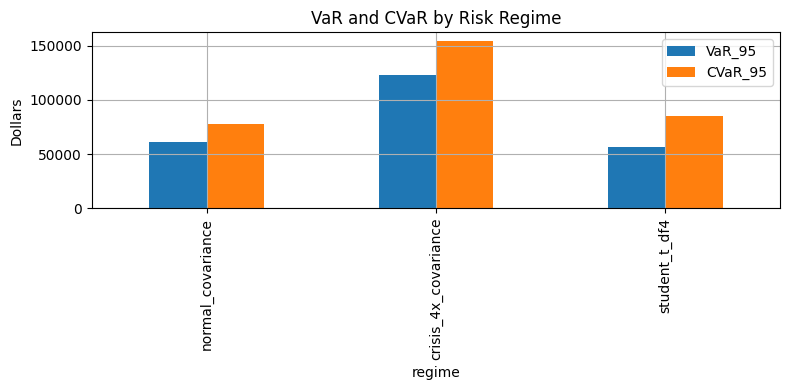

In [19]:
plot_df = stress_df.set_index("regime")[["VaR_95", "CVaR_95"]]
ax = plot_df.plot(kind = "bar", figsize = (8, 4))
ax.set_title("VaR and CVaR by Risk Regime")
ax.set_ylabel("Dollars")
ax.grid(True)
plt.tight_layout()
plt.show()

## 18. Loss-distribution plots

The next figures show the empirical simulated loss distributions for the same AAPL proposal under normal and crisis covariance.

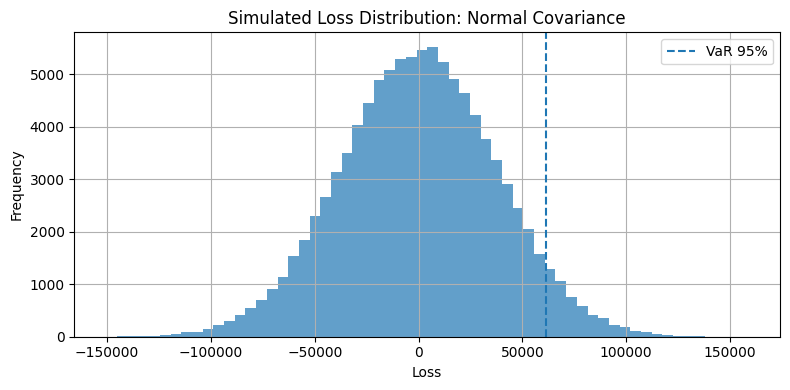

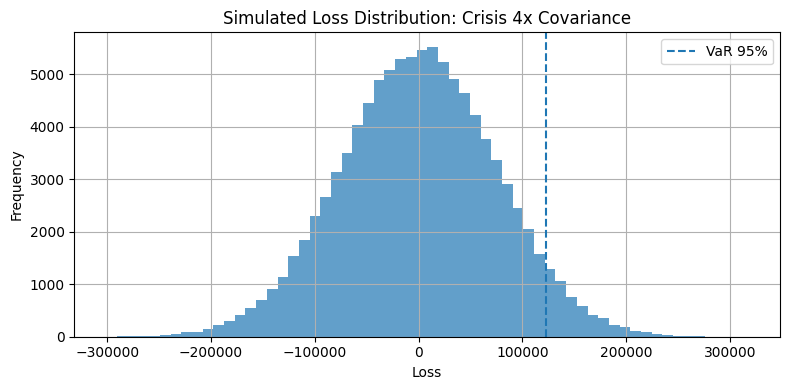

In [20]:
normal_losses = base_shield.simulate_losses_for_plot(stress_trade, portfolio)
crisis_losses = crisis_shield.simulate_losses_for_plot(stress_trade, portfolio)

plt.figure(figsize = (8, 4))
plt.hist(normal_losses, bins = 60, alpha = 0.7)
plt.axvline(np.quantile(normal_losses, 0.95), linestyle = "--", label = "VaR 95%")
plt.title("Simulated Loss Distribution: Normal Covariance")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize = (8, 4))
plt.hist(crisis_losses, bins = 60, alpha = 0.7)
plt.axvline(np.quantile(crisis_losses, 0.95), linestyle = "--", label = "VaR 95%")
plt.title("Simulated Loss Distribution: Crisis 4x Covariance")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 19. Simple model-card style summary

The shield should be documented like a model: assumptions, limits, failure modes, and governance actions.

In [21]:
model_card = {
    "system_name": "Agentic Finance Distributional Risk Shield",
    "purpose": "Gate LLM-proposed financial actions before execution.",
    "input_contract": "ProposedAction Pydantic schema.",
    "portfolio_context": "PortfolioState with exposures, covariance matrix, symbols, ADV, and metadata.",
    "risk_measures": ["VaR 95%", "CVaR 95%", "tail-loss probability", "concentration", "gross exposure", "liquidity ADV fraction"],
    "hard_rejects": ["restricted symbol", "notional breach", "missing risk universe", "gross exposure breach", "concentration breach", "tail probability breach"],
    "soft_escalations": ["CVaR breach", "VaR breach", "liquidity breach when policy permits escalation", "missing liquidity (ADV) data"],
    "fail_closed": True,
    "known_limitations": [
        "Synthetic covariance matrix for demonstration.",
        "No real order-book impact model.",
        "Option treatment is delta-only, not full Greeks or volatility surface.",
        "Rates example uses a separate DV01 check rather than full term-structure simulation.",
        "Monte Carlo metrics carry sampling error; decisions near a policy threshold need a larger n_simulations to be stable.",
        "The negotiator's bisection assumes admissibility is monotone in trade size.",
    ],
}

print(json.dumps(model_card, indent = 2))

{
  "system_name": "Agentic Finance Distributional Risk Shield",
  "purpose": "Gate LLM-proposed financial actions before execution.",
  "input_contract": "ProposedAction Pydantic schema.",
  "portfolio_context": "PortfolioState with exposures, covariance matrix, symbols, ADV, and metadata.",
  "risk_measures": [
    "VaR 95%",
    "CVaR 95%",
    "tail-loss probability",
    "concentration",
    "gross exposure",
    "liquidity ADV fraction"
  ],
  "hard_rejects": [
    "restricted symbol",
    "notional breach",
    "missing risk universe",
    "gross exposure breach",
    "concentration breach",
    "tail probability breach"
  ],
  "soft_escalations": [
    "CVaR breach",
    "VaR breach",
    "liquidity breach when policy permits escalation",
    "missing liquidity (ADV) data"
  ],
  "fail_closed": true,
  "known_limitations": [
    "Synthetic covariance matrix for demonstration.",
    "No real order-book impact model.",
    "Option treatment is delta-only, not full Greeks or volat

## 20. Consolidated audit log

The audit log combines all major scenario groups and exports them as a CSV when the notebook is run.

In [22]:
all_audit_frames = [
    core_audit_df,
    llm_audit_df.assign(scenario_set = "mock_llm_examples"),
    escalation_df,
    institutional_checks_df.assign(scenario_set = "institutional_checks"),
    comparison_df.assign(scenario_set = "buy_vs_sell"),
    option_df.assign(scenario_set = "option_delta"),
    multi_asset_df,
    basket_df.assign(scenario_set = "basket_rebalance"),
    stress_df.assign(scenario_set = "stress_regimes"),
    validation_df.rename(columns = {"payload_symbol": "symbol", "error": "reason"}).assign(scenario_set = "schema_validation"),
    dv01_df.assign(scenario_set = "dv01_checks"),
]

all_audit_df = pd.concat(all_audit_frames, ignore_index = True, sort = False)

ordered_columns = [
    "scenario_set", "audit_id", "status", "reason", "symbol", "side", "asset_class", "notional_value",
    "check_type", "basket_name", "regime",
    "VaR_95", "CVaR_95", "P_loss_gt_limit", "Expected_loss", "Loss_std",
    "Max_symbol_weight_after", "Gross_exposure_multiple_after", "Trade_ADV_fraction",
    "Stress_label", "Distribution", "Stress_multiplier",
    "Policy_name", "Loss_limit", "Max_VaR_95_limit", "Max_CVaR_95_limit",
    "trade_dv01", "dv01_after", "stress_bp", "stress_loss", "rules",
]
existing_columns = [column for column in ordered_columns if column in all_audit_df.columns]
all_audit_df = all_audit_df[existing_columns]

display(all_audit_df)

output_csv = "agentic_finance_giant_notebook_audit_log.csv"
all_audit_df.to_csv(output_csv, index = False)
print(f"Audit log exported to {output_csv}")

,scenario_set,audit_id,status,reason,symbol,side,asset_class,notional_value,check_type,basket_name,regime,VaR_95,CVaR_95,P_loss_gt_limit,Expected_loss,Loss_std,Max_symbol_weight_after,Gross_exposure_multiple_after,Trade_ADV_fraction,Stress_label,Distribution,Stress_multiplier,Policy_name,Loss_limit,Max_VaR_95_limit,Max_CVaR_95_limit,trade_dv01,dv01_after,stress_bp,stress_loss,rules
0,core_examples,a83209c2,allow,All deterministic and distributional checks pa...,AAPL,BUY,equity,"250,000.0000",NaN,NaN,NaN,"61,221.1317","76,656.5134",0.0150,113.3211,"37,309.2775",0.3600,1.0300,0.0000,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
1,core_examples,38961cac,reject,Tail-loss probability 8.94% exceeds limit 5.00%.,TSLA,BUY,equity,"800,000.0000",NaN,NaN,NaN,"98,222.3855","122,872.2362",0.0894,205.9199,"59,919.1368",0.4200,1.2500,0.0001,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
2,core_examples,a201c6d0,reject,"Notional $1,200,000.00 exceeds desk limit $1,0...",TSLA,BUY,equity,"1,200,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK
3,core_examples,7c3873c8,reject,Symbol GME is restricted.,GME,BUY,equity,"50,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK
4,core_examples,9b5f97a7,reject,Symbol SHIB is outside the approved risk unive...,SHIB,BUY,equity,"10,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
5,core_examples,d840f403,allow,All deterministic and distributional checks pa...,TSLA,SELL,equity,"200,000.0000",NaN,NaN,NaN,"45,042.7034","56,290.6742",0.0019,62.1768,"27,458.3287",0.2600,0.8500,0.0000,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
6,core_examples,59936ead,reject,Tail-loss probability 6.51% exceeds limit 5.00%.,NVDA,BUY,equity,"700,000.0000",NaN,NaN,NaN,"86,701.6130","108,484.4335",0.0651,196.7460,"52,969.8146",0.3600,1.2100,0.0001,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
7,mock_llm_examples,a744b182,allow,All deterministic and distributional checks pa...,AAPL,BUY,equity,"250,000.0000",NaN,NaN,NaN,"61,221.1317","76,656.5134",0.0150,113.3211,"37,309.2775",0.3600,1.0300,0.0000,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
8,mock_llm_examples,d60208fa,reject,Tail-loss probability 8.94% exceeds limit 5.00%.,TSLA,BUY,equity,"800,000.0000",NaN,NaN,NaN,"98,222.3855","122,872.2362",0.0894,205.9199,"59,919.1368",0.4200,1.2500,0.0001,base,normal,1.0000,Core teaching policy,"80,000.0000","75,000.0000","95,000.0000",NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...
9,mock_llm_examples,ce676454,reject,Symbol GME is restricted.,GME,BUY,equity,"50,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RESTRICTED_LIST_CHECK


Audit log exported to agentic_finance_giant_notebook_audit_log.csv


## 21. Multi-agent distributional shield

The previous sections use one typed proposal and one shield. Real financial workflows are closer to a committee: a research agent proposes, a technical agent challenges timing, a risk agent computes distributional loss, a compliance agent checks admissibility, and a portfolio-manager agent makes the final governance decision.

In this teaching implementation each agent applies deterministic typed rules; in a production system the internal reasoning could be an LLM-driven debate, but every operational handoff is still converted back into typed objects. Confidence scores are recorded in the audit trail and feed a minimum-support-mass threshold in the portfolio-manager aggregation, so they are load-bearing, not decorative. The distributional shield remains the execution gate: multi-agent consensus can recommend, escalate, or reject, but it cannot bypass the deterministic and tail-risk checks. The shield is evaluated exactly once per proposal, and the risk agent's vote provably derives from that same decision.


In [23]:
class AgentRole(str, Enum):
    RESEARCH = "research"
    TECHNICAL = "technical"
    RISK = "risk"
    COMPLIANCE = "compliance"
    PORTFOLIO_MANAGER = "portfolio_manager"


class AgentVote(str, Enum):
    SUPPORT = "support"
    CHALLENGE = "challenge"
    ESCALATE = "escalate"
    REJECT = "reject"
    ABSTAIN = "abstain"


class AgentOpinion(BaseModel):
    """Typed inter-agent message. No free-form output is allowed into the control plane."""
    model_config = {"extra": "forbid"}

    role: AgentRole
    agent_name: str
    vote: AgentVote
    confidence: float = Field(ge = 0.0, le = 1.0)
    reason: str
    metrics: dict[str, Any] = Field(default_factory = dict)


class MultiAgentDecision(BaseModel):
    """Governance object joining committee consensus with the distributional shield."""
    model_config = {"extra": "forbid"}

    committee_id: str
    proposal_payload: dict[str, Any]
    opinions: list[AgentOpinion]
    consensus_status: Literal["allow", "reject", "escalate"]
    consensus_reason: str
    shield_decision: DistributionalShieldDecision
    final_status: Literal["allow", "reject", "escalate"]
    final_reason: str


class ResearchAgent:
    def review(self, proposal: ProposedAction, portfolio_state: PortfolioState) -> AgentOpinion:
        rationale = proposal.rationale.lower()
        positive_terms = ["earnings", "cash", "growth", "hedge", "diversification", "valuation", "momentum"]
        score = sum(term in rationale for term in positive_terms)
        vote = AgentVote.SUPPORT if score >= 1 else AgentVote.ABSTAIN
        confidence = min(0.95, 0.55 + 0.10 * score)
        return AgentOpinion(
            role = AgentRole.RESEARCH,
            agent_name = "FundamentalResearchAgent",
            vote = vote,
            confidence = confidence,
            reason = "Rationale contains an identifiable investment or hedging thesis." if vote == AgentVote.SUPPORT else "No clear research thesis was detected.",
            metrics = {"thesis_keyword_score": score},
        )


class TechnicalAgent:
    def review(self, proposal: ProposedAction, portfolio_state: PortfolioState) -> AgentOpinion:
        crowded_symbols = {"TSLA", "NVDA", "GME", "AMC"}
        if proposal.symbol in crowded_symbols and proposal.side == "BUY":
            return AgentOpinion(
                role = AgentRole.TECHNICAL,
                agent_name = "TechnicalTimingAgent",
                vote = AgentVote.ESCALATE,
                confidence = 0.70,
                reason = "Buy trade is in a crowded/high-beta name; timing confirmation is required.",
                metrics = {"crowded_symbol": True},
            )
        return AgentOpinion(
            role = AgentRole.TECHNICAL,
            agent_name = "TechnicalTimingAgent",
            vote = AgentVote.SUPPORT,
            confidence = 0.62,
            reason = "No technical crowding flag was triggered.",
            metrics = {"crowded_symbol": False},
        )


class RiskAgent:
    def __init__(self, shield: DistributionalRiskShield):
        self.shield = shield

    def review(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
        shield_decision: Optional[DistributionalShieldDecision] = None,
    ) -> AgentOpinion:
        # The orchestrator passes in the already-computed shield decision so the
        # Monte Carlo simulation runs once and the vote derives from that decision.
        decision = shield_decision if shield_decision is not None else self.shield.evaluate(proposal, portfolio_state)
        if decision.status == "allow":
            vote = AgentVote.SUPPORT
        elif decision.status == "escalate":
            vote = AgentVote.ESCALATE
        else:
            vote = AgentVote.REJECT

        metrics: dict[str, Any] = {"shield_status": decision.status}
        if decision.distributional_report is not None:
            report = decision.distributional_report
            metrics.update({
                "VaR_95": report.var_95,
                "CVaR_95": report.cvar_95,
                "P_loss_gt_limit": report.probability_loss_exceeds_limit,
                "max_symbol_weight_after": report.max_symbol_weight_after,
                "gross_exposure_multiple_after": report.gross_exposure_multiple_after,
            })

        return AgentOpinion(
            role = AgentRole.RISK,
            agent_name = "DistributionalRiskAgent",
            vote = vote,
            confidence = 0.95,
            reason = decision.reason,
            metrics = metrics,
        )


class ComplianceAgent:
    def __init__(self, policy: RiskPolicy):
        self.policy = policy

    def review(self, proposal: ProposedAction, portfolio_state: PortfolioState) -> AgentOpinion:
        if proposal.symbol in self.policy.restricted_list:
            return AgentOpinion(
                role = AgentRole.COMPLIANCE,
                agent_name = "ComplianceAgent",
                vote = AgentVote.REJECT,
                confidence = 1.0,
                reason = f"{proposal.symbol} is on the restricted list.",
                metrics = {"restricted_list_hit": True},
            )
        if proposal.symbol not in portfolio_state.symbols:
            return AgentOpinion(
                role = AgentRole.COMPLIANCE,
                agent_name = "ComplianceAgent",
                vote = AgentVote.REJECT,
                confidence = 1.0,
                reason = f"{proposal.symbol} is outside the approved trading universe.",
                metrics = {"outside_universe": True},
            )
        return AgentOpinion(
            role = AgentRole.COMPLIANCE,
            agent_name = "ComplianceAgent",
            vote = AgentVote.SUPPORT,
            confidence = 0.98,
            reason = "No compliance block was detected.",
            metrics = {"restricted_list_hit": False, "outside_universe": False},
        )


class PortfolioManagerAgent:
    def aggregate(
        self,
        proposal: ProposedAction,
        opinions: list[AgentOpinion],
        shield_decision: DistributionalShieldDecision,
    ) -> tuple[Literal["allow", "reject", "escalate"], str]:
        votes = [opinion.vote for opinion in opinions]
        risk_or_compliance_reject = any(
            opinion.vote == AgentVote.REJECT and opinion.role in {AgentRole.RISK, AgentRole.COMPLIANCE}
            for opinion in opinions
        )
        if risk_or_compliance_reject or shield_decision.status == "reject":
            return "reject", "At least one hard gate rejected the action; the committee fails closed."
        if AgentVote.ESCALATE in votes or shield_decision.status == "escalate":
            return "escalate", "The action is not blocked, but one or more agents require human PM review."
        support_opinions = [opinion for opinion in opinions if opinion.vote == AgentVote.SUPPORT]
        support_count = len(support_opinions)
        # Confidence is load-bearing: three lukewarm supporters are not enough.
        support_confidence_mass = sum(opinion.confidence for opinion in support_opinions)
        if support_count >= 3 and support_confidence_mass >= 2.0 and shield_decision.status == "allow":
            return "allow", "Committee support and distributional shield approval are aligned."
        return "escalate", "The committee did not reach enough confident support for automatic execution."


class MultiAgentShieldOrchestrator:
    def __init__(self, shield: DistributionalRiskShield, policy: RiskPolicy):
        self.shield = shield
        self.research_agent = ResearchAgent()
        self.technical_agent = TechnicalAgent()
        self.risk_agent = RiskAgent(shield = shield)
        self.compliance_agent = ComplianceAgent(policy = policy)
        self.pm_agent = PortfolioManagerAgent()

    def evaluate(self, proposal: ProposedAction, portfolio_state: PortfolioState) -> MultiAgentDecision:
        committee_id = str(uuid.uuid4())[:8]
        # The shield is evaluated exactly once; the risk agent votes on that decision.
        shield_decision = self.shield.evaluate(proposal, portfolio_state)
        opinions = [
            self.research_agent.review(proposal, portfolio_state),
            self.technical_agent.review(proposal, portfolio_state),
            self.compliance_agent.review(proposal, portfolio_state),
            self.risk_agent.review(proposal, portfolio_state, shield_decision = shield_decision),
        ]
        consensus_status, consensus_reason = self.pm_agent.aggregate(
            proposal = proposal,
            opinions = opinions,
            shield_decision = shield_decision,
        )

        # Final status is the stricter of committee consensus and shield status.
        precedence = {"allow": 0, "escalate": 1, "reject": 2}
        final_status = max([consensus_status, shield_decision.status], key = lambda status: precedence[status])
        if final_status == "reject":
            final_reason = f"Rejected by governance/shield: {consensus_reason} Shield reason: {shield_decision.reason}"
        elif final_status == "escalate":
            final_reason = f"Escalated by governance/shield: {consensus_reason} Shield reason: {shield_decision.reason}"
        else:
            final_reason = "Approved by multi-agent committee and distributional shield."

        return MultiAgentDecision(
            committee_id = committee_id,
            proposal_payload = proposal.model_dump(mode = "json"),
            opinions = opinions,
            consensus_status = consensus_status,
            consensus_reason = consensus_reason,
            shield_decision = shield_decision,
            final_status = final_status,
            final_reason = final_reason,
        )


print("Multi-agent shield contracts and agents defined.")


Multi-agent shield contracts and agents defined.


In [24]:
def opinion_to_row(decision: MultiAgentDecision, opinion: AgentOpinion) -> dict[str, Any]:
    row = {
        "committee_id": decision.committee_id,
        "symbol": decision.proposal_payload.get("symbol"),
        "side": decision.proposal_payload.get("side"),
        "notional_value": decision.proposal_payload.get("notional_value"),
        "role": opinion.role.value,
        "agent_name": opinion.agent_name,
        "vote": opinion.vote.value,
        "confidence": opinion.confidence,
        "reason": opinion.reason,
    }
    for key, value in opinion.metrics.items():
        row[f"metric_{key}"] = value
    return row


def multiagent_decision_to_row(decision: MultiAgentDecision) -> dict[str, Any]:
    shield_row = decision_to_row(decision.shield_decision)
    return {
        "committee_id": decision.committee_id,
        "symbol": decision.proposal_payload.get("symbol"),
        "side": decision.proposal_payload.get("side"),
        "asset_class": decision.proposal_payload.get("asset_class"),
        "notional_value": decision.proposal_payload.get("notional_value"),
        "consensus_status": decision.consensus_status,
        "final_status": decision.final_status,
        "consensus_reason": decision.consensus_reason,
        "final_reason": decision.final_reason,
        "shield_status": decision.shield_decision.status,
        "shield_reason": decision.shield_decision.reason,
        "shield_audit_id": decision.shield_decision.audit_id,
        "shield_rules": shield_row.get("rules"),
        "VaR_95": shield_row.get("VaR_95"),
        "CVaR_95": shield_row.get("CVaR_95"),
        "P_loss_gt_limit": shield_row.get("P_loss_gt_limit"),
        "Max_symbol_weight_after": shield_row.get("Max_symbol_weight_after"),
        "Gross_exposure_multiple_after": shield_row.get("Gross_exposure_multiple_after"),
    }


def run_multiagent_scenarios(
    proposals: list[ProposedAction],
    orchestrator: MultiAgentShieldOrchestrator,
    portfolio_state: PortfolioState,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    decision_rows = []
    opinion_rows = []
    for proposal in proposals:
        decision = orchestrator.evaluate(proposal = proposal, portfolio_state = portfolio_state)
        decision_rows.append(multiagent_decision_to_row(decision))
        opinion_rows.extend(opinion_to_row(decision, opinion) for opinion in decision.opinions)
        print("=" * 100)
        print(f"Committee {decision.committee_id}: {proposal.side} {proposal.symbol} ${proposal.notional_value:,.0f}")
        print(f"Final status: {decision.final_status.upper()}")
        print(decision.final_reason)
        print("Agent votes:", ", ".join(f"{op.role.value}={op.vote.value}" for op in decision.opinions))
    return pd.DataFrame(decision_rows), pd.DataFrame(opinion_rows)


multiagent_orchestrator = MultiAgentShieldOrchestrator(shield = shield, policy = policy)

multiagent_proposals = [
    ProposedAction(
        symbol = "MSFT",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 75_000.0,
        sector = "Technology",
        rationale = "Earnings quality, cash-flow resilience, and diversification versus existing single-name risk.",
    ),
    ProposedAction(
        symbol = "NVDA",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 300_000.0,
        sector = "Technology",
        rationale = "Momentum and AI data-center growth thesis, but position sizing should be challenged.",
    ),
    ProposedAction(
        symbol = "GME",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 50_000.0,
        sector = "Consumer Discretionary",
        rationale = "Short-term momentum trade suggested by social sentiment.",
    ),
    ProposedAction(
        symbol = "TLT",
        asset_class = AssetClass.ETF,
        side = "BUY",
        notional_value = 175_000.0,
        sector = "Rates",
        rationale = "Hedge duration risk and diversify equity beta under a downside macro scenario.",
    ),
]

multiagent_decision_df, multiagent_opinion_df = run_multiagent_scenarios(
    proposals = multiagent_proposals,
    orchestrator = multiagent_orchestrator,
    portfolio_state = portfolio,
)

display(multiagent_decision_df)
display(multiagent_opinion_df)

multiagent_decision_df.to_csv("agentic_finance_multiagent_decision_log.csv", index = False)
multiagent_opinion_df.to_csv("agentic_finance_multiagent_opinion_log.csv", index = False)
print("Saved multi-agent CSV logs.")


Committee f33b44bf: BUY MSFT $75,000
Final status: ALLOW
Approved by multi-agent committee and distributional shield.
Agent votes: research=support, technical=support, compliance=support, risk=support
Committee 87e95c91: BUY NVDA $300,000
Final status: ESCALATE
Escalated by governance/shield: The action is not blocked, but one or more agents require human PM review. Shield reason: All deterministic and distributional checks passed.
Agent votes: research=support, technical=escalate, compliance=support, risk=support
Committee baddba10: BUY GME $50,000
Final status: REJECT
Rejected by governance/shield: At least one hard gate rejected the action; the committee fails closed. Shield reason: Symbol GME is restricted.
Agent votes: research=support, technical=escalate, compliance=reject, risk=reject
Committee 9f4b6fcd: BUY TLT $175,000
Final status: ALLOW
Approved by multi-agent committee and distributional shield.
Agent votes: research=support, technical=support, compliance=support, risk=supp

,committee_id,symbol,side,asset_class,notional_value,consensus_status,final_status,consensus_reason,final_reason,shield_status,shield_reason,shield_audit_id,shield_rules,VaR_95,CVaR_95,P_loss_gt_limit,Max_symbol_weight_after,Gross_exposure_multiple_after
0,f33b44bf,MSFT,BUY,equity,"75,000.0000",allow,allow,Committee support and distributional shield ap...,Approved by multi-agent committee and distribu...,allow,All deterministic and distributional checks pa...,52cfbab7,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...,"55,838.9657","69,975.2938",0.0090,0.2600,0.9600
1,87e95c91,NVDA,BUY,equity,"300,000.0000",escalate,escalate,"The action is not blocked, but one or more age...",Escalated by governance/shield: The action is ...,allow,All deterministic and distributional checks pa...,77e9398e,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...,"67,243.0285","84,310.3822",0.0246,0.2600,1.0500
2,baddba10,GME,BUY,equity,"50,000.0000",reject,reject,At least one hard gate rejected the action; th...,Rejected by governance/shield: At least one ha...,reject,Symbol GME is restricted.,3517cd72,RESTRICTED_LIST_CHECK,NaN,NaN,NaN,NaN,NaN
3,9f4b6fcd,TLT,BUY,etf,"175,000.0000",allow,allow,Committee support and distributional shield ap...,Approved by multi-agent committee and distribu...,allow,All deterministic and distributional checks pa...,fb2fb930,RESTRICTED_LIST_CHECK | NOTIONAL_LIMIT_CHECK |...,"53,995.5646","67,448.6020",0.0070,0.2600,1.0000


,committee_id,symbol,side,notional_value,role,agent_name,vote,confidence,reason,metric_thesis_keyword_score,metric_crowded_symbol,metric_restricted_list_hit,metric_outside_universe,metric_shield_status,metric_VaR_95,metric_CVaR_95,metric_P_loss_gt_limit,metric_max_symbol_weight_after,metric_gross_exposure_multiple_after
0,f33b44bf,MSFT,BUY,"75,000.0000",research,FundamentalResearchAgent,support,0.8500,Rationale contains an identifiable investment ...,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f33b44bf,MSFT,BUY,"75,000.0000",technical,TechnicalTimingAgent,support,0.6200,No technical crowding flag was triggered.,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,f33b44bf,MSFT,BUY,"75,000.0000",compliance,ComplianceAgent,support,0.9800,No compliance block was detected.,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN
3,f33b44bf,MSFT,BUY,"75,000.0000",risk,DistributionalRiskAgent,support,0.9500,All deterministic and distributional checks pa...,NaN,NaN,NaN,NaN,allow,"55,838.9657","69,975.2938",0.0090,0.2600,0.9600
4,87e95c91,NVDA,BUY,"300,000.0000",research,FundamentalResearchAgent,support,0.7500,Rationale contains an identifiable investment ...,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,87e95c91,NVDA,BUY,"300,000.0000",technical,TechnicalTimingAgent,escalate,0.7000,Buy trade is in a crowded/high-beta name; timi...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,87e95c91,NVDA,BUY,"300,000.0000",compliance,ComplianceAgent,support,0.9800,No compliance block was detected.,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN
7,87e95c91,NVDA,BUY,"300,000.0000",risk,DistributionalRiskAgent,support,0.9500,All deterministic and distributional checks pa...,NaN,NaN,NaN,NaN,allow,"67,243.0285","84,310.3822",0.0246,0.2600,1.0500
8,baddba10,GME,BUY,"50,000.0000",research,FundamentalResearchAgent,support,0.6500,Rationale contains an identifiable investment ...,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,baddba10,GME,BUY,"50,000.0000",technical,TechnicalTimingAgent,escalate,0.7000,Buy trade is in a crowded/high-beta name; timi...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved multi-agent CSV logs.


## 22. Multi-agent architecture statement

The multi-agent version should be read as a governance layer, not as a replacement for the risk engine. The research and technical agents can create reasons to trade; the compliance and risk agents impose non-negotiable admissibility constraints; the portfolio-manager agent aggregates committee opinions; and the distributional shield remains the final executable control. This preserves the central thesis of agentic finance: stochastic agents may propose, debate, and prioritize, but typed contracts and deterministic/distributional controls decide what can actually reach execution.


## 23. Final architecture statement

The strongest version of the system is:

\[
\text{LLM proposes}
\rightarrow
\text{schema types}
\rightarrow
\text{static admissibility checks}
\rightarrow
\text{portfolio-aware distributional checks}
\rightarrow
\text{execution routing}
\rightarrow
\text{audit log}.
\]

This is the finance-grade interpretation:

> The LLM is allowed to generate a candidate action, but the deterministic and distributional shields decide whether that action is institutionally and financially admissible.

## 24. Agent negotiator shielding

A stronger institutional design is not only a committee that votes, but a committee that **negotiates the admissible action** before execution. The negotiator layer receives the original trade request and lets specialist agents bargain over size, liquidity, tail risk, compliance, and execution terms.

The important control principle is unchanged: negotiation may reduce or condition a proposal, but it cannot weaken the deterministic or distributional shield. The final negotiated proposal is submitted again to the distributional shield, and the system fails closed if the negotiated terms remain unsafe. Two design details matter: protective execution terms (staged execution, kill switches), once required in any round, are never relaxed by a later round; and the risk negotiator's bisection search assumes admissibility is monotone in trade size, which holds for trades that increase absolute exposure — offsetting trades would require a grid search instead.

\[
\text{proposal}
\rightarrow
\text{agent negotiation}
\rightarrow
\text{revised typed proposal}
\rightarrow
\text{distributional shield}
\rightarrow
\text{execute / escalate / reject}.
\]


In [25]:

class NegotiationVote(str, Enum):
    ACCEPT = "accept"
    COUNTER = "counter"
    ESCALATE = "escalate"
    REJECT = "reject"


class NegotiationOffer(BaseModel):
    """Typed counteroffer produced by a specialist negotiation agent."""
    model_config = {"extra": "forbid"}

    round_index: int
    role: AgentRole
    agent_name: str
    vote: NegotiationVote
    proposed_notional_value: float = Field(ge = 0.0)
    confidence: float = Field(ge = 0.0, le = 1.0)
    reason: str
    binding_terms: dict[str, Any] = Field(default_factory = dict)
    diagnostics: dict[str, Any] = Field(default_factory = dict)


class NegotiationOutcome(BaseModel):
    """Final auditable object for negotiated shielding."""
    model_config = {"extra": "forbid"}

    session_id: str
    original_proposal_payload: dict[str, Any]
    negotiated_proposal_payload: dict[str, Any]
    offers: list[NegotiationOffer]
    negotiation_status: Literal["accepted", "rejected", "escalated"]
    negotiation_reason: str
    final_shield_decision: DistributionalShieldDecision
    final_status: Literal["allow", "reject", "escalate"]
    final_reason: str
    negotiated_terms: dict[str, Any] = Field(default_factory = dict)


class ComplianceNegotiator:
    def __init__(self, policy: RiskPolicy):
        self.policy = policy

    def negotiate(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
        round_index: int,
    ) -> NegotiationOffer:
        if proposal.symbol in self.policy.restricted_list:
            return NegotiationOffer(
                round_index = round_index,
                role = AgentRole.COMPLIANCE,
                agent_name = "ComplianceNegotiator",
                vote = NegotiationVote.REJECT,
                proposed_notional_value = 0.0,
                confidence = 1.0,
                reason = f"{proposal.symbol} is restricted; no negotiated size is admissible.",
                binding_terms = {"hard_block": "restricted_list"},
            )
        if proposal.symbol not in portfolio_state.symbols:
            return NegotiationOffer(
                round_index = round_index,
                role = AgentRole.COMPLIANCE,
                agent_name = "ComplianceNegotiator",
                vote = NegotiationVote.REJECT,
                proposed_notional_value = 0.0,
                confidence = 1.0,
                reason = f"{proposal.symbol} is outside the approved universe; negotiation cannot legalize it.",
                binding_terms = {"hard_block": "outside_approved_universe"},
            )
        return NegotiationOffer(
            round_index = round_index,
            role = AgentRole.COMPLIANCE,
            agent_name = "ComplianceNegotiator",
            vote = NegotiationVote.ACCEPT,
            proposed_notional_value = proposal.notional_value,
            confidence = 0.99,
            reason = "Compliance accepts the symbol and action type subject to final shield review.",
            binding_terms = {"compliance_review": "passed"},
        )


class LiquidityNegotiator:
    def __init__(self, policy: RiskPolicy):
        self.policy = policy

    def negotiate(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
        round_index: int,
    ) -> NegotiationOffer:
        adv = portfolio_state.adv_notional.get(proposal.symbol)
        if adv is None or adv <= 0:
            # Zero ADV is as unverifiable as missing ADV: never silently floor the
            # trade to zero and label it accepted; require a human liquidity review.
            return NegotiationOffer(
                round_index = round_index,
                role = AgentRole.RISK,
                agent_name = "LiquidityNegotiator",
                vote = NegotiationVote.ESCALATE,
                proposed_notional_value = proposal.notional_value,
                confidence = 0.65,
                reason = "No usable ADV estimate is available; liquidity must be manually reviewed.",
                binding_terms = {"manual_liquidity_review": True},
            )
        max_liquid_notional = adv * self.policy.max_adv_fraction
        proposed_notional = min(proposal.notional_value, max_liquid_notional)
        vote = NegotiationVote.ACCEPT if proposed_notional == proposal.notional_value else NegotiationVote.COUNTER
        return NegotiationOffer(
            round_index = round_index,
            role = AgentRole.RISK,
            agent_name = "LiquidityNegotiator",
            vote = vote,
            proposed_notional_value = proposed_notional,
            confidence = 0.90,
            reason = "Liquidity accepts the requested size." if vote == NegotiationVote.ACCEPT else "Liquidity counteroffers a smaller notional based on ADV limits.",
            binding_terms = {
                "max_adv_fraction": self.policy.max_adv_fraction,
                "adv_notional": adv,
                "max_liquid_notional": max_liquid_notional,
            },
        )


class DistributionalRiskNegotiator:
    def __init__(self, shield: DistributionalRiskShield):
        self.shield = shield

    def _scaled_proposal(self, proposal: ProposedAction, notional_value: float) -> ProposedAction:
        return proposal.model_copy(update = {"notional_value": float(notional_value)})

    def _passes_or_escalates(self, decision: DistributionalShieldDecision) -> bool:
        return decision.status in {"allow", "escalate"}

    def negotiate(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
        round_index: int,
    ) -> NegotiationOffer:
        current_decision = self.shield.evaluate(proposal, portfolio_state)
        if current_decision.status == "allow":
            report = current_decision.distributional_report
            diagnostics = {} if report is None else {
                "VaR_95": report.var_95,
                "CVaR_95": report.cvar_95,
                "P_loss_gt_limit": report.probability_loss_exceeds_limit,
                "max_symbol_weight_after": report.max_symbol_weight_after,
                "gross_exposure_multiple_after": report.gross_exposure_multiple_after,
            }
            return NegotiationOffer(
                round_index = round_index,
                role = AgentRole.RISK,
                agent_name = "DistributionalRiskNegotiator",
                vote = NegotiationVote.ACCEPT,
                proposed_notional_value = proposal.notional_value,
                confidence = 0.96,
                reason = "Distributional risk accepts the current notional.",
                binding_terms = {"risk_status": "allow"},
                diagnostics = diagnostics,
            )

        # Bisection assumes the shield verdict is monotone in notional. This holds
        # when the trade strictly increases absolute exposure (buys from a flat or
        # long book); trades offsetting a large existing short need a grid search.
        lower = 0.0
        upper = proposal.notional_value
        best_notional = 0.0
        best_decision = self.shield.evaluate(self._scaled_proposal(proposal, 0.0), portfolio_state)

        for _ in range(24):
            midpoint = 0.5 * (lower + upper)
            midpoint_proposal = self._scaled_proposal(proposal, midpoint)
            midpoint_decision = self.shield.evaluate(midpoint_proposal, portfolio_state)
            if self._passes_or_escalates(midpoint_decision):
                best_notional = midpoint
                best_decision = midpoint_decision
                lower = midpoint
            else:
                upper = midpoint

        report = best_decision.distributional_report
        diagnostics = {"original_shield_status": current_decision.status, "negotiated_shield_status": best_decision.status}
        if report is not None:
            diagnostics.update({
                "VaR_95": report.var_95,
                "CVaR_95": report.cvar_95,
                "P_loss_gt_limit": report.probability_loss_exceeds_limit,
                "max_symbol_weight_after": report.max_symbol_weight_after,
                "gross_exposure_multiple_after": report.gross_exposure_multiple_after,
            })

        if best_notional <= 1.0:
            return NegotiationOffer(
                round_index = round_index,
                role = AgentRole.RISK,
                agent_name = "DistributionalRiskNegotiator",
                vote = NegotiationVote.REJECT,
                proposed_notional_value = 0.0,
                confidence = 0.96,
                reason = "No economically meaningful notional survives the distributional risk shield.",
                binding_terms = {"hard_block": "distributional_risk"},
                diagnostics = diagnostics,
            )

        vote = NegotiationVote.ESCALATE if best_decision.status == "escalate" else NegotiationVote.COUNTER
        return NegotiationOffer(
            round_index = round_index,
            role = AgentRole.RISK,
            agent_name = "DistributionalRiskNegotiator",
            vote = vote,
            proposed_notional_value = best_notional,
            confidence = 0.95,
            reason = "Risk counteroffers the largest notional that survives tail-risk checks." if vote == NegotiationVote.COUNTER else "Risk found only an escalated notional; human approval is required.",
            binding_terms = {"max_distributional_notional": best_notional},
            diagnostics = diagnostics,
        )


class ExecutionNegotiator:
    def negotiate(
        self,
        proposal: ProposedAction,
        portfolio_state: PortfolioState,
        round_index: int,
    ) -> NegotiationOffer:
        adv = portfolio_state.adv_notional.get(proposal.symbol, np.nan)
        adv_fraction = np.nan if pd.isna(adv) or adv == 0 else proposal.notional_value / adv
        if not pd.isna(adv_fraction) and adv_fraction > 0.05:
            vote = NegotiationVote.COUNTER
            terms = {
                "execution_style": "staged_vwap",
                "child_order_count": 5,
                "max_participation_rate": 0.10,
                "kill_switch": "cancel_if_spread_or_volatility_doubles",
            }
            reason = "Execution requires staged participation because the trade is large versus ADV."
        else:
            vote = NegotiationVote.ACCEPT
            terms = {
                "execution_style": "standard_limit_or_vwap",
                "child_order_count": 1,
                "max_participation_rate": 0.10,
            }
            reason = "Execution accepts the negotiated notional with standard controls."
        return NegotiationOffer(
            round_index = round_index,
            role = AgentRole.PORTFOLIO_MANAGER,
            agent_name = "ExecutionNegotiator",
            vote = vote,
            proposed_notional_value = proposal.notional_value,
            confidence = 0.80,
            reason = reason,
            binding_terms = terms,
            diagnostics = {"trade_adv_fraction": adv_fraction},
        )


class AgentNegotiatorShield:
    def __init__(self, shield: DistributionalRiskShield, policy: RiskPolicy, max_rounds: int = 4):
        self.shield = shield
        self.max_rounds = max_rounds
        self.negotiators = [
            ComplianceNegotiator(policy = policy),
            LiquidityNegotiator(policy = policy),
            DistributionalRiskNegotiator(shield = shield),
            ExecutionNegotiator(),
        ]

    def _scaled_proposal(self, proposal: ProposedAction, notional_value: float) -> ProposedAction:
        return proposal.model_copy(update = {"notional_value": float(notional_value)})

    @staticmethod
    def _merge_binding_terms(negotiated_terms: dict[str, Any], new_terms: dict[str, Any]) -> None:
        """Merge offer terms without ever weakening an already-recorded protection."""
        for key, value in new_terms.items():
            if key == "hard_block" and "hard_block" in negotiated_terms:
                continue  # The first recorded block reason names the gate that actually fired.
            if key == "execution_style" and negotiated_terms.get(key) == "staged_vwap":
                continue  # Staged execution, once required, is never relaxed to standard.
            if key == "child_order_count" and key in negotiated_terms:
                value = max(value, negotiated_terms[key])
            if key == "max_participation_rate" and key in negotiated_terms:
                value = min(value, negotiated_terms[key])
            negotiated_terms[key] = value

    def negotiate_and_shield(self, proposal: ProposedAction, portfolio_state: PortfolioState) -> NegotiationOutcome:
        session_id = str(uuid.uuid4())[:8]
        offers: list[NegotiationOffer] = []
        current_proposal = proposal
        negotiated_terms: dict[str, Any] = {}
        negotiation_status: Literal["accepted", "rejected", "escalated"] = "accepted"
        negotiation_reason = "Negotiation converged."
        converged = False

        for round_index in range(1, self.max_rounds + 1):
            round_offers: list[NegotiationOffer] = []
            rejected = False
            for negotiator in self.negotiators:
                offer = negotiator.negotiate(current_proposal, portfolio_state, round_index)
                round_offers.append(offer)
                self._merge_binding_terms(negotiated_terms, offer.binding_terms)
                if offer.vote == NegotiationVote.REJECT:
                    # Fail closed immediately: later negotiators do not run this round,
                    # so their terms can neither dilute nor overwrite the block reason,
                    # and no execution terms are ever stamped onto a rejected trade.
                    rejected = True
                    break
            offers.extend(round_offers)

            if rejected:
                current_proposal = self._scaled_proposal(current_proposal, 0.0)
                negotiation_status = "rejected"
                negotiation_reason = "At least one negotiation agent issued a hard reject."
                converged = True
                break

            # Escalation is re-assessed every round: an early escalate that is later
            # resolved by a size reduction does not stick to the final outcome.
            round_escalated = any(offer.vote == NegotiationVote.ESCALATE for offer in round_offers)
            negotiation_status = "escalated" if round_escalated else "accepted"
            negotiation_reason = (
                "At least one negotiation agent requires human approval."
                if round_escalated
                else "Negotiation converged."
            )

            counter_notional = min(offer.proposed_notional_value for offer in round_offers)
            if abs(counter_notional - current_proposal.notional_value) < 1.0:
                converged = True
                break
            current_proposal = self._scaled_proposal(current_proposal, counter_notional)

        if not converged:
            negotiation_reason = (
                "Reached the maximum number of negotiation rounds without convergence; "
                "the smallest surviving size is used."
            )

        final_shield_decision = self.shield.evaluate(current_proposal, portfolio_state)
        precedence = {"allow": 0, "escalate": 1, "reject": 2}
        status_candidates = [final_shield_decision.status]
        if negotiation_status == "rejected":
            status_candidates.append("reject")
        elif negotiation_status == "escalated":
            status_candidates.append("escalate")
        else:
            status_candidates.append("allow")
        final_status = max(status_candidates, key = lambda status: precedence[status])

        if final_status == "allow":
            final_reason = "Negotiated terms and final distributional shield both allow execution."
        elif final_status == "escalate":
            final_reason = "Negotiated terms are conditionally acceptable but require human approval or final shield escalation."
        else:
            final_reason = "Negotiation failed closed or the final distributional shield rejected the proposal."

        return NegotiationOutcome(
            session_id = session_id,
            original_proposal_payload = proposal.model_dump(mode = "json"),
            negotiated_proposal_payload = current_proposal.model_dump(mode = "json"),
            offers = offers,
            negotiation_status = negotiation_status,
            negotiation_reason = negotiation_reason,
            final_shield_decision = final_shield_decision,
            final_status = final_status,
            final_reason = final_reason,
            negotiated_terms = negotiated_terms,
        )


print("Agent negotiator shielding contracts defined.")


Agent negotiator shielding contracts defined.


In [26]:

def negotiation_offer_to_row(outcome: NegotiationOutcome, offer: NegotiationOffer) -> dict[str, Any]:
    row = {
        "session_id": outcome.session_id,
        "symbol": outcome.original_proposal_payload.get("symbol"),
        "side": outcome.original_proposal_payload.get("side"),
        "original_notional_value": outcome.original_proposal_payload.get("notional_value"),
        "negotiated_notional_value": outcome.negotiated_proposal_payload.get("notional_value"),
        "round_index": offer.round_index,
        "role": offer.role.value,
        "agent_name": offer.agent_name,
        "vote": offer.vote.value,
        "proposed_notional_value": offer.proposed_notional_value,
        "confidence": offer.confidence,
        "reason": offer.reason,
    }
    for key, value in offer.binding_terms.items():
        row[f"term_{key}"] = value
    for key, value in offer.diagnostics.items():
        row[f"diagnostic_{key}"] = value
    return row


def negotiation_outcome_to_row(outcome: NegotiationOutcome) -> dict[str, Any]:
    shield_row = decision_to_row(outcome.final_shield_decision)
    return {
        "session_id": outcome.session_id,
        "symbol": outcome.original_proposal_payload.get("symbol"),
        "side": outcome.original_proposal_payload.get("side"),
        "asset_class": outcome.original_proposal_payload.get("asset_class"),
        "original_notional_value": outcome.original_proposal_payload.get("notional_value"),
        "negotiated_notional_value": outcome.negotiated_proposal_payload.get("notional_value"),
        "notional_reduction": outcome.original_proposal_payload.get("notional_value") - outcome.negotiated_proposal_payload.get("notional_value"),
        "negotiation_status": outcome.negotiation_status,
        "final_status": outcome.final_status,
        "negotiation_reason": outcome.negotiation_reason,
        "final_reason": outcome.final_reason,
        "shield_status": outcome.final_shield_decision.status,
        "shield_reason": outcome.final_shield_decision.reason,
        "execution_style": outcome.negotiated_terms.get("execution_style"),
        "child_order_count": outcome.negotiated_terms.get("child_order_count"),
        "max_participation_rate": outcome.negotiated_terms.get("max_participation_rate"),
        "VaR_95": shield_row.get("VaR_95"),
        "CVaR_95": shield_row.get("CVaR_95"),
        "P_loss_gt_limit": shield_row.get("P_loss_gt_limit"),
        "Max_symbol_weight_after": shield_row.get("Max_symbol_weight_after"),
        "Gross_exposure_multiple_after": shield_row.get("Gross_exposure_multiple_after"),
    }


def run_negotiator_shield_scenarios(
    proposals: list[ProposedAction],
    negotiator_shield: AgentNegotiatorShield,
    portfolio_state: PortfolioState,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    outcome_rows = []
    offer_rows = []
    for proposal in proposals:
        outcome = negotiator_shield.negotiate_and_shield(proposal = proposal, portfolio_state = portfolio_state)
        outcome_rows.append(negotiation_outcome_to_row(outcome))
        offer_rows.extend(negotiation_offer_to_row(outcome, offer) for offer in outcome.offers)
        print("=" * 100)
        print(f"Negotiation {outcome.session_id}: {proposal.side} {proposal.symbol} ${proposal.notional_value:,.0f}")
        print(f"Negotiated notional: ${outcome.negotiated_proposal_payload.get('notional_value'):,.0f}")
        print(f"Final status: {outcome.final_status.upper()}")
        print(outcome.final_reason)
    return pd.DataFrame(outcome_rows), pd.DataFrame(offer_rows)


agent_negotiator_shield = AgentNegotiatorShield(shield = shield, policy = policy)

negotiator_proposals = [
    ProposedAction(
        symbol = "MSFT",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 120_000.0,
        sector = "Technology",
        rationale = "High-quality earnings and cash-flow resilience, but size should be negotiated against risk budget.",
    ),
    ProposedAction(
        symbol = "NVDA",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 650_000.0,
        sector = "Technology",
        rationale = "AI momentum trade with strong thesis, requiring notional bargaining and staged execution.",
    ),
    ProposedAction(
        symbol = "TSLA",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 500_000.0,
        sector = "Consumer Discretionary",
        rationale = "Crowded high-beta trade; negotiator must reduce size or escalate.",
    ),
    ProposedAction(
        symbol = "GME",
        asset_class = AssetClass.EQUITY,
        side = "BUY",
        notional_value = 50_000.0,
        sector = "Consumer Discretionary",
        rationale = "Social-sentiment momentum proposal used to demonstrate fail-closed negotiation.",
    ),
    ProposedAction(
        symbol = "TLT",
        asset_class = AssetClass.ETF,
        side = "BUY",
        notional_value = 250_000.0,
        sector = "Rates",
        rationale = "Duration hedge proposed as a defensive portfolio overlay.",
    ),
    ProposedAction(
        symbol = "HY_CDS",
        asset_class = AssetClass.CDS,
        side = "BUY",
        notional_value = 5_000_000.0,
        sector = "Credit",
        rationale = "High-yield credit overlay with attractive carry, but size far exceeds prudent ADV participation and must be negotiated down.",
    ),
]

negotiator_outcome_df, negotiator_offer_df = run_negotiator_shield_scenarios(
    proposals = negotiator_proposals,
    negotiator_shield = agent_negotiator_shield,
    portfolio_state = portfolio,
)

display(negotiator_outcome_df)
display(negotiator_offer_df)

negotiator_outcome_df.to_csv("agentic_finance_agent_negotiator_shield_outcomes.csv", index = False)
negotiator_offer_df.to_csv("agentic_finance_agent_negotiator_shield_offers.csv", index = False)
print("Saved agent negotiator shielding CSV logs.")


Negotiation ab94ab08: BUY MSFT $120,000
Negotiated notional: $120,000
Final status: ALLOW
Negotiated terms and final distributional shield both allow execution.
Negotiation 064884a6: BUY NVDA $650,000
Negotiated notional: $565,460
Final status: ESCALATE
Negotiated terms are conditionally acceptable but require human approval or final shield escalation.


Negotiation adec0db6: BUY TSLA $500,000
Negotiated notional: $484,637
Final status: ESCALATE
Negotiated terms are conditionally acceptable but require human approval or final shield escalation.
Negotiation edb60cf3: BUY GME $50,000
Negotiated notional: $0
Final status: REJECT
Negotiation failed closed or the final distributional shield rejected the proposal.
Negotiation 937a9f8c: BUY TLT $250,000
Negotiated notional: $250,000
Final status: ALLOW
Negotiated terms and final distributional shield both allow execution.


Negotiation 564311ee: BUY HY_CDS $5,000,000
Negotiated notional: $1,000,000
Final status: ALLOW
Negotiated terms and final distributional shield both allow execution.


,session_id,symbol,side,asset_class,original_notional_value,negotiated_notional_value,notional_reduction,negotiation_status,final_status,negotiation_reason,final_reason,shield_status,shield_reason,execution_style,child_order_count,max_participation_rate,VaR_95,CVaR_95,P_loss_gt_limit,Max_symbol_weight_after,Gross_exposure_multiple_after
0,ab94ab08,MSFT,BUY,equity,"120,000.0000","120,000.0000",0.0000,accepted,allow,Negotiation converged.,Negotiated terms and final distributional shie...,allow,All deterministic and distributional checks pa...,standard_limit_or_vwap,1.0000,0.1000,"56,889.6216","71,273.2383",0.0098,0.2600,0.9780
1,064884a6,NVDA,BUY,equity,"650,000.0000","565,459.5941","84,540.4059",escalated,escalate,At least one negotiation agent requires human ...,Negotiated terms are conditionally acceptable ...,escalate,"CVaR 95% $100,160.23 exceeds limit $95,000.00.",standard_limit_or_vwap,1.0000,0.1000,"80,000.6724","100,160.2340",0.0500,0.3062,1.1562
2,adec0db6,TSLA,BUY,equity,"500,000.0000","484,637.2306","15,362.7694",escalated,escalate,At least one negotiation agent requires human ...,Negotiated terms are conditionally acceptable ...,escalate,"CVaR 95% $100,226.15 exceeds limit $95,000.00.",standard_limit_or_vwap,1.0000,0.1000,"80,000.2557","100,226.1533",0.0500,0.2939,1.1239
3,edb60cf3,GME,BUY,equity,"50,000.0000",0.0000,"50,000.0000",rejected,reject,At least one negotiation agent issued a hard r...,Negotiation failed closed or the final distrib...,reject,Symbol GME is restricted.,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,937a9f8c,TLT,BUY,etf,"250,000.0000","250,000.0000",0.0000,accepted,allow,Negotiation converged.,Negotiated terms and final distributional shie...,allow,All deterministic and distributional checks pa...,standard_limit_or_vwap,1.0000,0.1000,"53,849.3588","67,353.7501",0.0072,0.2600,1.0300
5,564311ee,HY_CDS,BUY,cds,"5,000,000.0000","999,999.9404","4,000,000.0596",accepted,allow,Negotiation converged.,Negotiated terms and final distributional shie...,allow,All deterministic and distributional checks pa...,staged_vwap,5.0000,0.1000,"48,384.2783","60,494.5068",0.0038,0.3600,1.2500


,session_id,symbol,side,original_notional_value,negotiated_notional_value,round_index,role,agent_name,vote,proposed_notional_value,confidence,reason,term_compliance_review,term_max_adv_fraction,term_adv_notional,term_max_liquid_notional,term_risk_status,diagnostic_VaR_95,diagnostic_CVaR_95,diagnostic_P_loss_gt_limit,diagnostic_max_symbol_weight_after,diagnostic_gross_exposure_multiple_after,term_execution_style,term_child_order_count,term_max_participation_rate,diagnostic_trade_adv_fraction,term_max_distributional_notional,diagnostic_original_shield_status,diagnostic_negotiated_shield_status,term_hard_block,term_kill_switch
0,ab94ab08,MSFT,BUY,"120,000.0000","120,000.0000",1,compliance,ComplianceNegotiator,accept,"120,000.0000",0.9900,Compliance accepts the symbol and action type ...,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ab94ab08,MSFT,BUY,"120,000.0000","120,000.0000",1,risk,LiquidityNegotiator,accept,"120,000.0000",0.9000,Liquidity accepts the requested size.,NaN,0.1500,"6,000,000,000.0000","900,000,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ab94ab08,MSFT,BUY,"120,000.0000","120,000.0000",1,risk,DistributionalRiskNegotiator,accept,"120,000.0000",0.9600,Distributional risk accepts the current notional.,NaN,NaN,NaN,NaN,allow,"56,889.6216","71,273.2383",0.0098,0.2600,0.9780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ab94ab08,MSFT,BUY,"120,000.0000","120,000.0000",1,portfolio_manager,ExecutionNegotiator,accept,"120,000.0000",0.8000,Execution accepts the negotiated notional with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,standard_limit_or_vwap,1.0000,0.1000,0.0000,NaN,NaN,NaN,NaN,NaN
4,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",1,compliance,ComplianceNegotiator,accept,"650,000.0000",0.9900,Compliance accepts the symbol and action type ...,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",1,risk,LiquidityNegotiator,accept,"650,000.0000",0.9000,Liquidity accepts the requested size.,NaN,0.1500,"12,000,000,000.0000","1,800,000,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",1,risk,DistributionalRiskNegotiator,escalate,"565,459.5941",0.9500,Risk found only an escalated notional; human a...,NaN,NaN,NaN,NaN,NaN,"80,000.6724","100,160.2340",0.0500,0.3062,1.1562,NaN,NaN,NaN,NaN,"565,459.5941",reject,escalate,NaN,NaN
7,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",1,portfolio_manager,ExecutionNegotiator,accept,"650,000.0000",0.8000,Execution accepts the negotiated notional with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,standard_limit_or_vwap,1.0000,0.1000,0.0001,NaN,NaN,NaN,NaN,NaN
8,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",2,compliance,ComplianceNegotiator,accept,"565,459.5941",0.9900,Compliance accepts the symbol and action type ...,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,064884a6,NVDA,BUY,"650,000.0000","565,459.5941",2,risk,LiquidityNegotiator,accept,"565,459.5941",0.9000,Liquidity accepts the requested size.,NaN,0.1500,"12,000,000,000.0000","1,800,000,000.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved agent negotiator shielding CSV logs.


## 25. Negotiator shielding architecture statement

The negotiator shield introduces a new distinction:

- A **committee shield** asks whether agents support, challenge, escalate, or reject a proposed action.
- A **negotiator shield** asks whether the action can be transformed into a smaller, more conditional, more executable, and still typed action that survives institutional risk controls.

This is the finance analogue of safe bargaining: agents can negotiate down risk, add execution constraints, or require escalation, but they cannot negotiate away the hard constraints. The final typed action remains subject to the deterministic and distributional shield.